In [29]:
import pandas as pd

# Loading the identified flight-related CSV files directly
try:
    flights_df = pd.read_csv('flights.csv')
    airlines_df = pd.read_csv('airlines.csv')
    airports_df = pd.read_csv('airports.csv')
    print("\nDataFrames loaded successfully. First 5 rows of each DataFrame:")
    print("\nflights_df.head():\n", flights_df.head())
    print("\nairlines_df.head():\n", airlines_df.head())
    print("\nairports_df.head():\n", airports_df.head())
except FileNotFoundError as e:
    print(f"Error loading file: {e}. Please ensure the file names are correct.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# After loading, we can start with basic EDA like df.info(), df.describe(), etc.

/tmp/ipykernel_4122/3034533355.py:5: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  flights_df = pd.read_csv('flights.csv')



DataFrames loaded successfully. First 5 rows of each DataFrame:

flights_df.head():
    YEAR  MONTH  DAY  DAY_OF_WEEK AIRLINE  FLIGHT_NUMBER TAIL_NUMBER  \
0  2015      1    1            4      AS             98      N407AS   
1  2015      1    1            4      AA           2336      N3KUAA   
2  2015      1    1            4      US            840      N171US   
3  2015      1    1            4      AA            258      N3HYAA   
4  2015      1    1            4      AS            135      N527AS   

  ORIGIN_AIRPORT DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  ...  ARRIVAL_TIME  \
0            ANC                 SEA                    5  ...         408.0   
1            LAX                 PBI                   10  ...         741.0   
2            SFO                 CLT                   20  ...         811.0   
3            LAX                 MIA                   20  ...         756.0   
4            SEA                 ANC                   25  ...         259.0   

   ARR

### Análise Inicial do DataFrame `flights_df`

In [30]:
print("Informações do flights_df:")
flights_df.info()
print("\nEstatísticas Descritivas do flights_df:")
display(flights_df.describe())

Informações do flights_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              object 
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          object 
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVER

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,5.726566e+06,5.714008e+06,5.819079e+06,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.493808e+03,1.476491e+03,4.407057e+00,2.609863e-03,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,5.071647e+02,5.263197e+02,3.927130e+01,5.102012e-02,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,-8.700000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,1.110000e+03,1.059000e+03,-1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,1.520000e+03,1.512000e+03,-5.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,1.918000e+03,1.917000e+03,8.000000e+00,0.000000e+00,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,2.400000e+03,2.400000e+03,1.971000e+03,1.000000e+00,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03


### Análise Inicial do DataFrame `airlines_df`

In [31]:
print("Informações do airlines_df:")
airlines_df.info()
print("\nEstatísticas Descritivas do airlines_df:")
display(airlines_df.describe())

Informações do airlines_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   IATA_CODE  14 non-null     object
 1   AIRLINE    14 non-null     object
dtypes: object(2)
memory usage: 356.0+ bytes

Estatísticas Descritivas do airlines_df:


,IATA_CODE,AIRLINE
count,14,14
unique,14,14
top,UA,United Air Lines Inc.
freq,1,1


### Análise Inicial do DataFrame `airports_df`

In [32]:
print("Informações do airports_df:")
airports_df.info()
print("\nEstatísticas Descritivas do airports_df:")
display(airports_df.describe())

Informações do airports_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IATA_CODE  322 non-null    object 
 1   AIRPORT    322 non-null    object 
 2   CITY       322 non-null    object 
 3   STATE      322 non-null    object 
 4   COUNTRY    322 non-null    object 
 5   LATITUDE   319 non-null    float64
 6   LONGITUDE  319 non-null    float64
dtypes: float64(2), object(5)
memory usage: 17.7+ KB

Estatísticas Descritivas do airports_df:


,LATITUDE,LONGITUDE
count,319.000000,319.000000
mean,38.981244,-98.378964
std,8.616736,21.523492
min,13.483450,-176.646030
25%,33.652040,-110.839385
50%,39.297610,-93.403070
75%,43.154675,-82.722995
max,71.285450,-64.798560


### Mesclando os DataFrames

In [33]:
# --- Step 1: Mesclar flights_df com airlines_df para obter o nome completo da companhia aérea ---
# Seleciona e renomeia colunas de airlines_df antes de mesclar para evitar conflitos
airlines_renamed = airlines_df.rename(columns={'AIRLINE': 'AIRLINE_NAME'})[['IATA_CODE', 'AIRLINE_NAME']]

merged_df = pd.merge(flights_df, airlines_renamed,
                     left_on='AIRLINE', right_on='IATA_CODE',
                     how='left')

# Remove a coluna IATA_CODE redundante (que veio de airlines_df)
merged_df.drop(columns=['IATA_CODE'], inplace=True)


# --- Step 2: Mesclar com airports_df para obter informações do aeroporto de origem ---
# Seleciona e renomeia colunas de airports_df para o aeroporto de origem, adicionando prefixos específicos
airports_origin_renamed = airports_df.rename(columns={
    'IATA_CODE': 'ORIGIN_IATA_CODE', # Esta será a chave de mesclagem
    'AIRPORT': 'ORIGIN_AIRPORT_NAME',
    'CITY': 'ORIGIN_CITY',
    'STATE': 'ORIGIN_STATE',
    'COUNTRY': 'ORIGIN_COUNTRY',
    'LATITUDE': 'ORIGIN_LATITUDE',
    'LONGITUDE': 'ORIGIN_LONGITUDE'
})[['ORIGIN_IATA_CODE', 'ORIGIN_AIRPORT_NAME', 'ORIGIN_CITY', 'ORIGIN_STATE', 'ORIGIN_COUNTRY', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE']]

merged_df = pd.merge(merged_df, airports_origin_renamed,
                     left_on='ORIGIN_AIRPORT', right_on='ORIGIN_IATA_CODE',
                     how='left')

# Remove a coluna ORIGIN_IATA_CODE redundante após a mesclagem
merged_df.drop(columns=['ORIGIN_IATA_CODE'], inplace=True)


# --- Step 3: Mesclar com airports_df novamente para obter informações do aeroporto de destino ---
# Seleciona e renomeia colunas de airports_df para o aeroporto de destino, adicionando prefixos específicos
airports_destination_renamed = airports_df.rename(columns={
    'IATA_CODE': 'DESTINATION_IATA_CODE', # Esta será a chave de mesclagem
    'AIRPORT': 'DESTINATION_AIRPORT_NAME',
    'CITY': 'DESTINATION_CITY',
    'STATE': 'DESTINATION_STATE',
    'COUNTRY': 'DESTINATION_COUNTRY',
    'LATITUDE': 'DESTINATION_LATITUDE',
    'LONGITUDE': 'DESTINATION_LONGITUDE'
})[['DESTINATION_IATA_CODE', 'DESTINATION_AIRPORT_NAME', 'DESTINATION_CITY', 'DESTINATION_STATE', 'DESTINATION_COUNTRY', 'DESTINATION_LATITUDE', 'DESTINATION_LONGITUDE']]

merged_df = pd.merge(merged_df, airports_destination_renamed,
                     left_on='DESTINATION_AIRPORT', right_on='DESTINATION_IATA_CODE',
                     how='left')

# Remove a coluna DESTINATION_IATA_CODE redundante após a mesclagem
merged_df.drop(columns=['DESTINATION_IATA_CODE'], inplace=True)

print("DataFrame mesclado criado com sucesso. Primeiras 20 linhas:")
display(merged_df.head(20))

print("\nInformações gerais do DataFrame mesclado:")
merged_df.info()

print("\nEstatísticas Descritivas do DataFrame mesclado:")
display(merged_df.describe())

DataFrame mesclado criado com sucesso. Primeiras 20 linhas:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ORIGIN_STATE,ORIGIN_COUNTRY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_AIRPORT_NAME,DESTINATION_CITY,DESTINATION_STATE,DESTINATION_COUNTRY,DESTINATION_LATITUDE,DESTINATION_LONGITUDE
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,AK,USA,61.17432,-149.99619,Seattle-Tacoma International Airport,Seattle,WA,USA,47.44898,-122.30931
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,CA,USA,33.94254,-118.40807,Palm Beach International Airport,West Palm Beach,FL,USA,26.68316,-80.09559
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,CA,USA,37.61900,-122.37484,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,CA,USA,33.94254,-118.40807,Miami International Airport,Miami,FL,USA,25.79325,-80.29056
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,WA,USA,47.44898,-122.30931,Ted Stevens Anchorage International Airport,Anchorage,AK,USA,61.17432,-149.99619
5,2015,1,1,4,DL,806,N3730B,SFO,MSP,25,...,CA,USA,37.61900,-122.37484,Minneapolis-Saint Paul International Airport,Minneapolis,MN,USA,44.88055,-93.21692
6,2015,1,1,4,NK,612,N635NK,LAS,MSP,25,...,NV,USA,36.08036,-115.15233,Minneapolis-Saint Paul International Airport,Minneapolis,MN,USA,44.88055,-93.21692
7,2015,1,1,4,US,2013,N584UW,LAX,CLT,30,...,CA,USA,33.94254,-118.40807,Charlotte Douglas International Airport,Charlotte,NC,USA,35.21401,-80.94313
8,2015,1,1,4,AA,1112,N3LAAA,SFO,DFW,30,...,CA,USA,37.61900,-122.37484,Dallas/Fort Worth International Airport,Dallas-Fort Worth,TX,USA,32.89595,-97.03720
9,2015,1,1,4,DL,1173,N826DN,LAS,ATL,30,...,NV,USA,36.08036,-115.15233,Hartsfield-Jackson Atlanta International Airport,Atlanta,GA,USA,33.64044,-84.42694



Informações gerais do DataFrame mesclado:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 44 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   YEAR                      int64  
 1   MONTH                     int64  
 2   DAY                       int64  
 3   DAY_OF_WEEK               int64  
 4   AIRLINE                   object 
 5   FLIGHT_NUMBER             int64  
 6   TAIL_NUMBER               object 
 7   ORIGIN_AIRPORT            object 
 8   DESTINATION_AIRPORT       object 
 9   SCHEDULED_DEPARTURE       int64  
 10  DEPARTURE_TIME            float64
 11  DEPARTURE_DELAY           float64
 12  TAXI_OUT                  float64
 13  WHEELS_OFF                float64
 14  SCHEDULED_TIME            float64
 15  ELAPSED_TIME              float64
 16  AIR_TIME                  float64
 17  DISTANCE                  int64  
 18  WHEELS_ON                 float64
 19  TAXI_IN             

,YEAR,MONTH,DAY,DAY_OF_WEEK,FLIGHT_NUMBER,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,...,CANCELLED,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,ORIGIN_LATITUDE,ORIGIN_LONGITUDE,DESTINATION_LATITUDE,DESTINATION_LONGITUDE
count,5819079.0,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.819079e+06,5.732926e+06,5.732926e+06,5.730032e+06,5.730032e+06,...,5.819079e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,1.063439e+06,5.328309e+06,5.328309e+06,5.328304e+06,5.328304e+06
mean,2015.0,6.524085e+00,1.570459e+01,3.926941e+00,2.173093e+03,1.329602e+03,1.335204e+03,9.370158e+00,1.607166e+01,1.357171e+03,...,1.544643e-02,1.348057e+01,7.615387e-02,1.896955e+01,2.347284e+01,2.915290e+00,3.663806e+01,-9.549123e+01,3.663795e+01,-9.549102e+01
std,0.0,3.405137e+00,8.783425e+00,1.988845e+00,1.757064e+03,4.837518e+02,4.964233e+02,3.708094e+01,8.895574e+00,4.980094e+02,...,1.233201e-01,2.800368e+01,2.143460e+00,4.816164e+01,4.319702e+01,2.043334e+01,5.999338e+00,1.815637e+01,5.999285e+00,1.815616e+01
min,2015.0,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-8.200000e+01,1.000000e+00,1.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.348345e+01,-1.766460e+02,1.348345e+01,-1.766460e+02
25%,2015.0,4.000000e+00,8.000000e+00,2.000000e+00,7.300000e+02,9.170000e+02,9.210000e+02,-5.000000e+00,1.100000e+01,9.350000e+02,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.289595e+01,-1.119778e+02,3.289595e+01,-1.119778e+02
50%,2015.0,7.000000e+00,1.600000e+01,4.000000e+00,1.690000e+03,1.325000e+03,1.330000e+03,-2.000000e+00,1.400000e+01,1.343000e+03,...,0.000000e+00,2.000000e+00,0.000000e+00,2.000000e+00,3.000000e+00,0.000000e+00,3.736186e+01,-9.025803e+01,3.736186e+01,-9.025803e+01
75%,2015.0,9.000000e+00,2.300000e+01,6.000000e+00,3.230000e+03,1.730000e+03,1.740000e+03,7.000000e+00,1.900000e+01,1.754000e+03,...,0.000000e+00,1.800000e+01,0.000000e+00,1.900000e+01,2.900000e+01,0.000000e+00,4.078839e+01,-8.168786e+01,4.078839e+01,-8.168786e+01
max,2015.0,1.200000e+01,3.100000e+01,7.000000e+00,9.855000e+03,2.359000e+03,2.400000e+03,1.988000e+03,2.250000e+02,2.400000e+03,...,1.000000e+00,1.134000e+03,5.730000e+02,1.971000e+03,1.331000e+03,1.211000e+03,7.128545e+01,-6.479856e+01,7.128545e+01,-6.479856e+01


### Análise de Atrasos por Companhia Aérea

Top 10 Companhias Aéreas com o maior número de atrasos e sua média de atraso:


,AIRLINE_NAME,NUMBER_OF_DELAYS,AVERAGE_DELAY
0,Southwest Airlines Co.,470767,29.418496
1,American Airlines Inc.,252191,34.148364
2,Delta Air Lines Inc.,250840,32.077424
3,Skywest Airlines Inc.,222435,32.437278
4,Atlantic Southeast Airlines,213217,35.198042
5,United Air Lines Inc.,186227,39.209314
6,American Eagle Airlines Inc.,103505,39.509202
7,JetBlue Airways,101998,38.132807
8,US Airways Inc.,76285,27.419925
9,Alaska Airlines Inc.,56953,22.562411


/tmp/ipykernel_4122/534105190.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AIRLINE_NAME', y='AVERAGE_DELAY', data=top_10_airlines, palette='viridis')


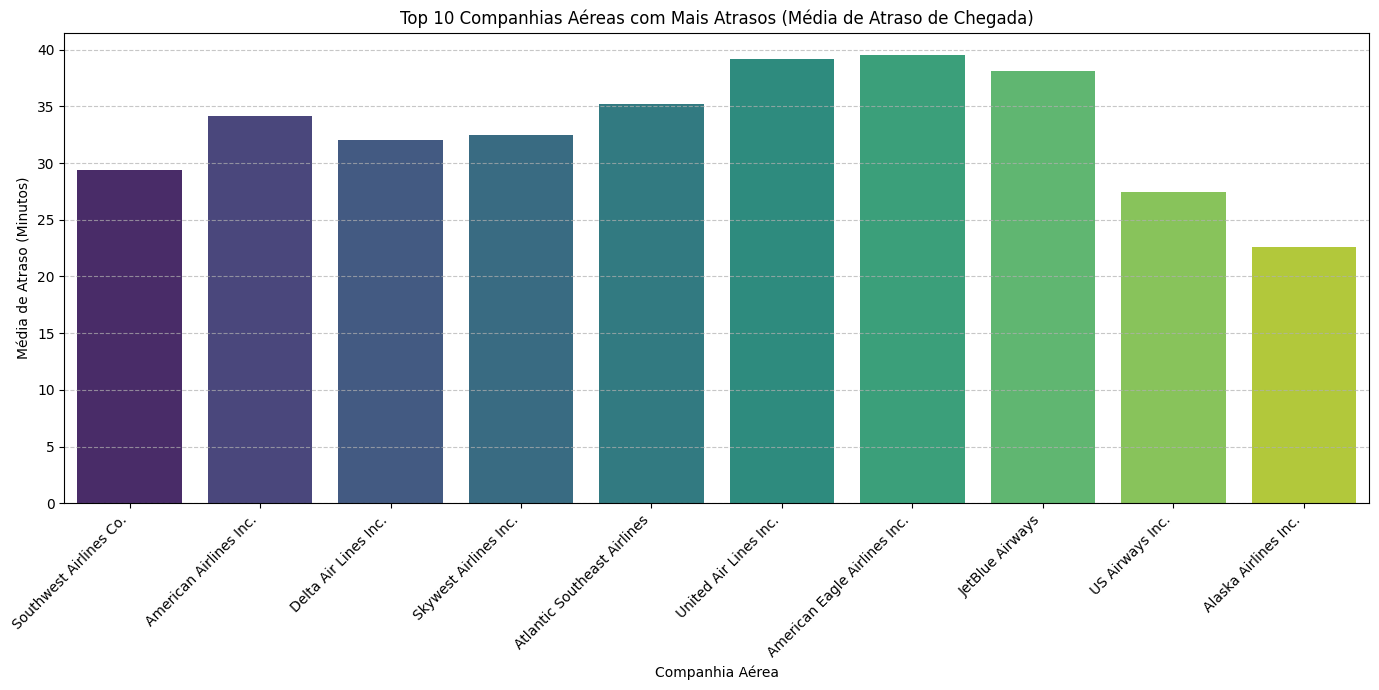

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar voos com atraso (ARRIVAL_DELAY > 0)
delayed_flights = merged_df[merged_df['ARRIVAL_DELAY'] > 0]

# Contar o número de atrasos por companhia aérea
delay_counts = delayed_flights['AIRLINE_NAME'].value_counts().reset_index()
delay_counts.columns = ['AIRLINE_NAME', 'NUMBER_OF_DELAYS']

# Calcular a média de atraso por companhia aérea
average_delay = delayed_flights.groupby('AIRLINE_NAME')['ARRIVAL_DELAY'].mean().reset_index()
average_delay.columns = ['AIRLINE_NAME', 'AVERAGE_DELAY']

# Mesclar os dois DataFrames para ter o número de atrasos e a média de atraso na mesma tabela
airline_delay_stats = pd.merge(delay_counts, average_delay, on='AIRLINE_NAME')

# Selecionar as 10 companhias aéreas com o maior número de atrasos
top_10_airlines = airline_delay_stats.nlargest(10, 'NUMBER_OF_DELAYS')

print("Top 10 Companhias Aéreas com o maior número de atrasos e sua média de atraso:")
display(top_10_airlines)

# Criar o gráfico de barras
plt.figure(figsize=(14, 7))
sns.barplot(x='AIRLINE_NAME', y='AVERAGE_DELAY', data=top_10_airlines, palette='viridis')
plt.title('Top 10 Companhias Aéreas com Mais Atrasos (Média de Atraso de Chegada)')
plt.xlabel('Companhia Aérea')
plt.ylabel('Média de Atraso (Minutos)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparação entre Atraso de Partida e Atraso de Chegada

Correlação entre Atraso de Partida e Atraso de Chegada: 0.94


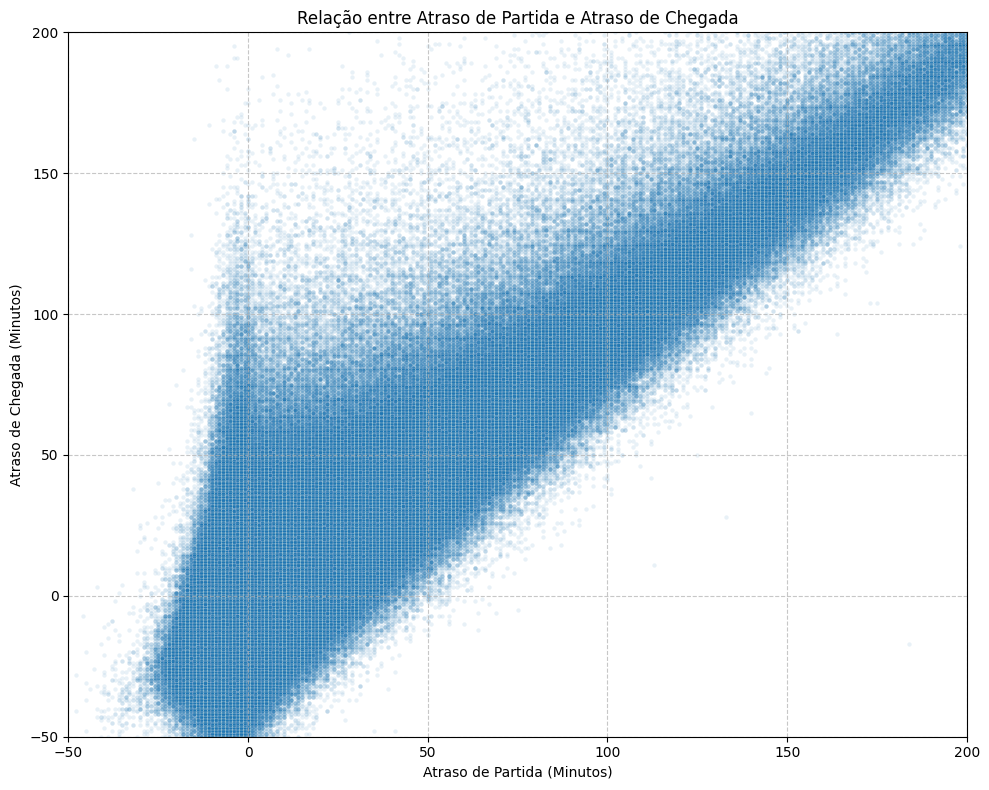

In [35]:
# Filtrar o DataFrame para incluir apenas voos com dados de atraso de partida e chegada
delay_comparison_df = merged_df[['DEPARTURE_DELAY', 'ARRIVAL_DELAY']].dropna()

# Calcular a correlação entre DEPARTURE_DELAY e ARRIVAL_DELAY
correlation = delay_comparison_df['DEPARTURE_DELAY'].corr(delay_comparison_df['ARRIVAL_DELAY'])
print(f"Correlação entre Atraso de Partida e Atraso de Chegada: {correlation:.2f}")

# Criar um gráfico de dispersão para visualizar a relação
plt.figure(figsize=(10, 8))
sns.scatterplot(x='DEPARTURE_DELAY', y='ARRIVAL_DELAY', data=delay_comparison_df, alpha=0.1, s=10)
plt.title('Relação entre Atraso de Partida e Atraso de Chegada')
plt.xlabel('Atraso de Partida (Minutos)')
plt.ylabel('Atraso de Chegada (Minutos)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(-50, 200) # Limitar o eixo X para melhor visualização dos dados mais densos
plt.ylim(-50, 200) # Limitar o eixo Y para melhor visualização dos dados mais densos
plt.tight_layout()
plt.show()

### Porcentagem de Voos Atrasados por Companhia Aérea

Porcentagem de Voos Atrasados por Companhia Aérea:


,AIRLINE_NAME,TOTAL_FLIGHTS,DELAYED_FLIGHTS,PERCENTAGE_DELAYED
10,Spirit Air Lines,117379,56887,48.464376
11,Frontier Airlines Inc.,90836,41232,45.391695
12,Hawaiian Airlines Inc.,76272,30179,39.567600
13,Virgin America,61903,24180,39.061112
8,US Airways Inc.,198715,76285,38.389150
7,JetBlue Airways,267048,101998,38.194632
3,Skywest Airlines Inc.,588353,222435,37.806385
0,Southwest Airlines Co.,1261855,470767,37.307535
4,Atlantic Southeast Airlines,571977,213217,37.277198
5,United Air Lines Inc.,515723,186227,36.109888


/tmp/ipykernel_4122/3730278624.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AIRLINE_NAME', y='PERCENTAGE_DELAYED', data=flight_delay_percentage_sorted, palette='magma')


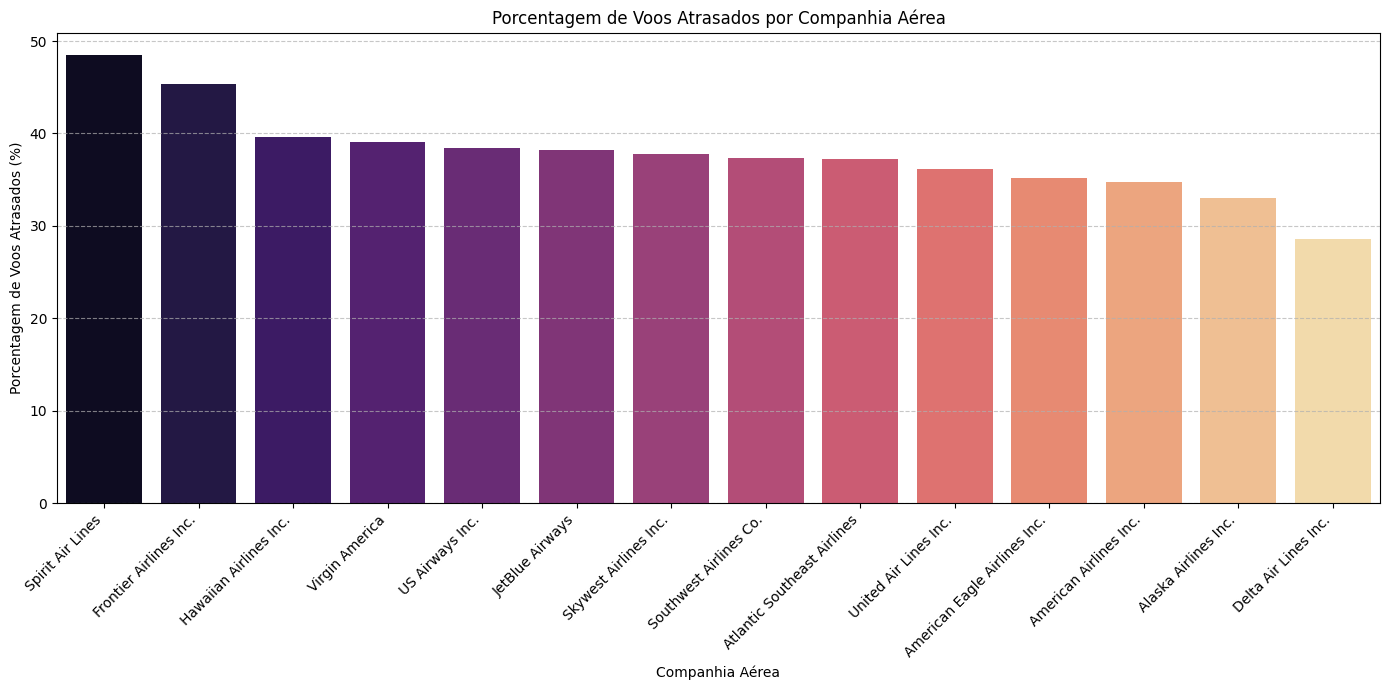

In [36]:
# Calcular o número total de voos por companhia aérea
total_flights_per_airline = merged_df['AIRLINE_NAME'].value_counts().reset_index()
total_flights_per_airline.columns = ['AIRLINE_NAME', 'TOTAL_FLIGHTS']

# Já temos 'delayed_flights' do análise anterior (voos com ARRIVAL_DELAY > 0)
# Contar o número de voos atrasados por companhia aérea
delayed_flights_per_airline = delayed_flights['AIRLINE_NAME'].value_counts().reset_index()
delayed_flights_per_airline.columns = ['AIRLINE_NAME', 'DELAYED_FLIGHTS']

# Mesclar os dois DataFrames
flight_delay_percentage = pd.merge(total_flights_per_airline,
                                   delayed_flights_per_airline,
                                   on='AIRLINE_NAME',
                                   how='left')

# Preencher NaN (se alguma companhia aérea não teve atrasos) com 0
flight_delay_percentage['DELAYED_FLIGHTS'] = flight_delay_percentage['DELAYED_FLIGHTS'].fillna(0)

# Calcular a porcentagem de voos atrasados
flight_delay_percentage['PERCENTAGE_DELAYED'] = (flight_delay_percentage['DELAYED_FLIGHTS'] / flight_delay_percentage['TOTAL_FLIGHTS']) * 100

# Ordenar por porcentagem de atraso em ordem decrescente
flight_delay_percentage_sorted = flight_delay_percentage.sort_values(by='PERCENTAGE_DELAYED', ascending=False)

print("Porcentagem de Voos Atrasados por Companhia Aérea:")
display(flight_delay_percentage_sorted)

# Visualizar a porcentagem de voos atrasados por companhia aérea
plt.figure(figsize=(14, 7))
sns.barplot(x='AIRLINE_NAME', y='PERCENTAGE_DELAYED', data=flight_delay_percentage_sorted, palette='magma')
plt.title('Porcentagem de Voos Atrasados por Companhia Aérea')
plt.xlabel('Companhia Aérea')
plt.ylabel('Porcentagem de Voos Atrasados (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Análise da Influência do Dia da Semana nos Atrasos

Porcentagem de Voos Atrasados por Dia da Semana:


,DAY_OF_WEEK_NAME,TOTAL_FLIGHTS,DELAYED_FLIGHTS,PERCENTAGE_DELAYED
1,Segunda-feira,865543,314978,36.390797
4,Terça-feira,844600,295171,34.948023
3,Quarta-feira,855897,304289,35.552058
0,Quinta-feira,872521,335560,38.458673
2,Sexta-feira,862209,326419,37.858454
6,Sábado,700545,224677,32.071744
5,Domingo,817764,285802,34.949203


/tmp/ipykernel_4122/1317029274.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DAY_OF_WEEK_NAME', y='PERCENTAGE_DELAYED', data=delay_by_day_percentage_sorted, palette='plasma')


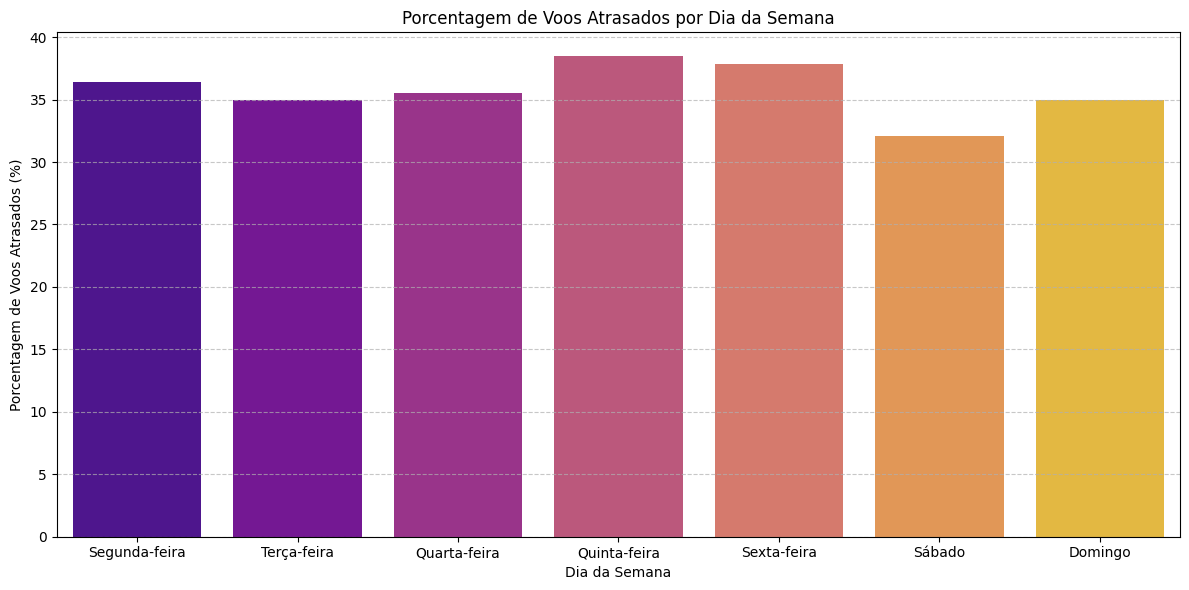

In [37]:
# Mapear o número do dia da semana para o nome do dia para melhor legibilidade
day_of_week_map = {
    1: 'Segunda-feira', 2: 'Terça-feira', 3: 'Quarta-feira',
    4: 'Quinta-feira', 5: 'Sexta-feira', 6: 'Sábado', 7: 'Domingo'
}
merged_df['DAY_OF_WEEK_NAME'] = merged_df['DAY_OF_WEEK'].map(day_of_week_map)

# Re-create 'delayed_flights' to ensure it includes the 'DAY_OF_WEEK_NAME' column
# This ensures consistency with 'merged_df' after 'DAY_OF_WEEK_NAME' has been added.
delayed_flights = merged_df[merged_df['ARRIVAL_DELAY'] > 0]

# Calcular o número total de voos por dia da semana
total_flights_by_day = merged_df['DAY_OF_WEEK_NAME'].value_counts().reset_index()
total_flights_by_day.columns = ['DAY_OF_WEEK_NAME', 'TOTAL_FLIGHTS']

# Contar o número de voos atrasados por dia da semana
delayed_flights_by_day = delayed_flights['DAY_OF_WEEK_NAME'].value_counts().reset_index()
delayed_flights_by_day.columns = ['DAY_OF_WEEK_NAME', 'DELAYED_FLIGHTS']

# Mesclar os dois DataFrames
delay_by_day_percentage = pd.merge(total_flights_by_day,
                                  delayed_flights_by_day,
                                  on='DAY_OF_WEEK_NAME',
                                  how='left')

# Preencher NaN (se algum dia da semana não teve atrasos) com 0
delay_by_day_percentage['DELAYED_FLIGHTS'] = delay_by_day_percentage['DELAYED_FLIGHTS'].fillna(0)

# Calcular a porcentagem de voos atrasados por dia da semana
delay_by_day_percentage['PERCENTAGE_DELAYED'] = (delay_by_day_percentage['DELAYED_FLIGHTS'] / delay_by_day_percentage['TOTAL_FLIGHTS']) * 100

# Ordenar pela ordem natural dos dias da semana
day_order = ['Segunda-feira', 'Terça-feira', 'Quarta-feira', 'Quinta-feira', 'Sexta-feira', 'Sábado', 'Domingo']
delay_by_day_percentage['DAY_OF_WEEK_NAME'] = pd.Categorical(delay_by_day_percentage['DAY_OF_WEEK_NAME'], categories=day_order, ordered=True)
delay_by_day_percentage_sorted = delay_by_day_percentage.sort_values('DAY_OF_WEEK_NAME')

print("Porcentagem de Voos Atrasados por Dia da Semana:")
display(delay_by_day_percentage_sorted)

# Visualizar a porcentagem de voos atrasados por dia da semana
plt.figure(figsize=(12, 6))
sns.barplot(x='DAY_OF_WEEK_NAME', y='PERCENTAGE_DELAYED', data=delay_by_day_percentage_sorted, palette='plasma')
plt.title('Porcentagem de Voos Atrasados por Dia da Semana')
plt.xlabel('Dia da Semana')
plt.ylabel('Porcentagem de Voos Atrasados (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Variação Mensal dos Atrasos de Chegada

Média de Atrasos de Chegada por Mês:


,MONTH,ARRIVAL_DELAY,MONTH_NAME
0,1,5.813583,Janeiro
1,2,8.320500,Fevereiro
2,3,4.920673,Março
3,4,3.163190,Abril
4,5,4.485019,Maio
5,6,9.601590,Junho
6,7,6.431775,Julho
7,8,4.607372,Agosto
8,9,-0.772571,Setembro
9,10,-0.780390,Outubro


/tmp/ipykernel_4122/989468920.py:22: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='MONTH_NAME', y='ARRIVAL_DELAY', data=delay_by_month_sorted, marker='o', palette='viridis')


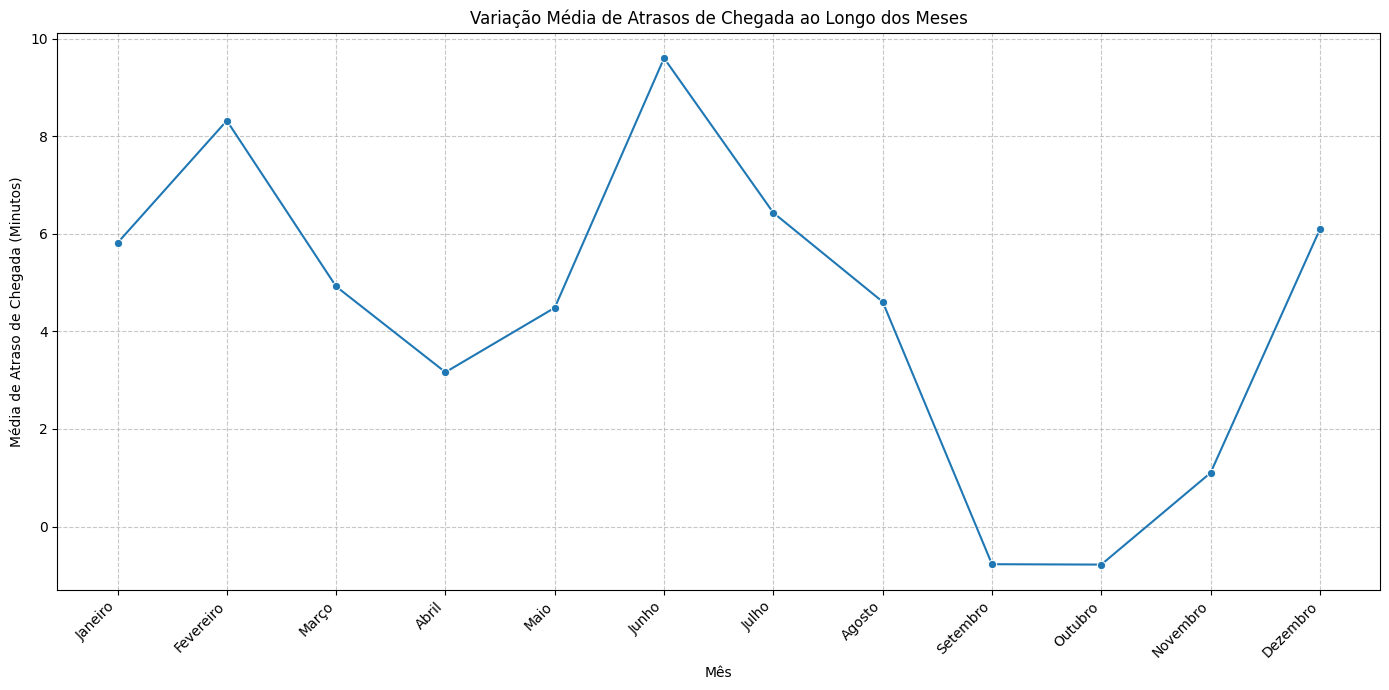

In [38]:
# Calcular a média de atraso de chegada por mês
delay_by_month = merged_df.groupby('MONTH')['ARRIVAL_DELAY'].mean().reset_index()

# Mapear números dos meses para nomes para melhor legibilidade
month_map = {
    1: 'Janeiro', 2: 'Fevereiro', 3: 'Março', 4: 'Abril',
    5: 'Maio', 6: 'Junho', 7: 'Julho', 8: 'Agosto',
    9: 'Setembro', 10: 'Outubro', 11: 'Novembro', 12: 'Dezembro'
}
delay_by_month['MONTH_NAME'] = delay_by_month['MONTH'].map(month_map)

# Ordenar os meses cronologicamente
month_order = ['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro']
delay_by_month['MONTH_NAME'] = pd.Categorical(delay_by_month['MONTH_NAME'], categories=month_order, ordered=True)
delay_by_month_sorted = delay_by_month.sort_values('MONTH_NAME')

print("Média de Atrasos de Chegada por Mês:")
display(delay_by_month_sorted)

# Criar o gráfico de linha
plt.figure(figsize=(14, 7))
sns.lineplot(x='MONTH_NAME', y='ARRIVAL_DELAY', data=delay_by_month_sorted, marker='o', palette='viridis')
plt.title('Variação Média de Atrasos de Chegada ao Longo dos Meses')
plt.xlabel('Mês')
plt.ylabel('Média de Atraso de Chegada (Minutos)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Principais Causas de Atraso

Total de Atrasos (em Minutos) por Causa:


,CAUSE,TOTAL_DELAY_MINUTES
3,LATE_AIRCRAFT_DELAY,24961931.0
2,AIRLINE_DELAY,20172956.0
0,AIR_SYSTEM_DELAY,14335762.0
4,WEATHER_DELAY,3100233.0
1,SECURITY_DELAY,80985.0


/tmp/ipykernel_4122/1875042653.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CAUSE', y='TOTAL_DELAY_MINUTES', data=total_delay_by_cause_sorted, palette='rocket')


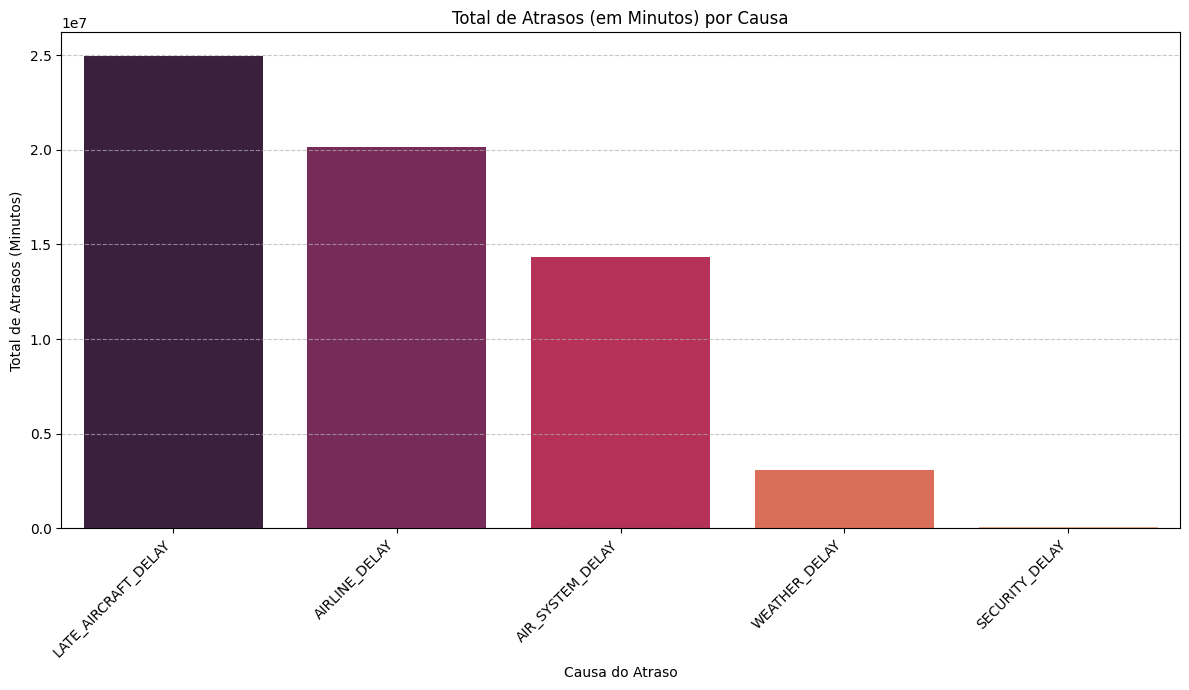

In [39]:
# Selecionar as colunas de causas de atraso
delay_cause_columns = ['AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']

# Preencher valores NaN com 0 para o cálculo da soma
delay_causes = merged_df[delay_cause_columns].fillna(0)

# Calcular a soma total de atrasos para cada causa
total_delay_by_cause = delay_causes.sum().reset_index()
total_delay_by_cause.columns = ['CAUSE', 'TOTAL_DELAY_MINUTES']

# Ordenar por total de atraso em ordem decrescente
total_delay_by_cause_sorted = total_delay_by_cause.sort_values(by='TOTAL_DELAY_MINUTES', ascending=False)

print("Total de Atrasos (em Minutos) por Causa:")
display(total_delay_by_cause_sorted)

# Criar o gráfico de barras para visualizar as causas de atraso
plt.figure(figsize=(12, 7))
sns.barplot(x='CAUSE', y='TOTAL_DELAY_MINUTES', data=total_delay_by_cause_sorted, palette='rocket')
plt.title('Total de Atrasos (em Minutos) por Causa')
plt.xlabel('Causa do Atraso')
plt.ylabel('Total de Atrasos (Minutos)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparação de Atrasos entre Fim de Semana e Dias Úteis

Média de Atraso de Chegada por Tipo de Dia (Fim de Semana vs. Dias Úteis):


,DAY_TYPE,ARRIVAL_DELAY
0,Weekday,4.909669
1,Weekend,2.985171


/tmp/ipykernel_4122/608499116.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DAY_TYPE', y='ARRIVAL_DELAY', data=average_delay_by_day_type, palette='coolwarm')


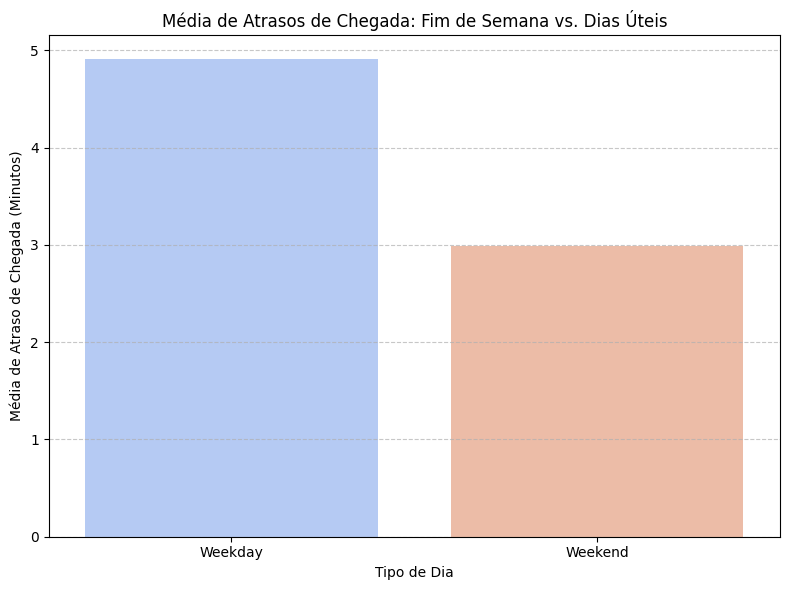

In [40]:
# Mapear o dia da semana para 'Weekday' ou 'Weekend'
# 1-5 são dias úteis (Segunda a Sexta), 6-7 são fim de semana (Sábado e Domingo)
merged_df['DAY_TYPE'] = merged_df['DAY_OF_WEEK'].apply(lambda x: 'Weekend' if x in [6, 7] else 'Weekday')

# Calcular a média de atraso de chegada por tipo de dia
average_delay_by_day_type = merged_df.groupby('DAY_TYPE')['ARRIVAL_DELAY'].mean().reset_index()

print("Média de Atraso de Chegada por Tipo de Dia (Fim de Semana vs. Dias Úteis):")
display(average_delay_by_day_type)

# Criar um gráfico de barras para visualizar a comparação
plt.figure(figsize=(8, 6))
sns.barplot(x='DAY_TYPE', y='ARRIVAL_DELAY', data=average_delay_by_day_type, palette='coolwarm')
plt.title('Média de Atrasos de Chegada: Fim de Semana vs. Dias Úteis')
plt.xlabel('Tipo de Dia')
plt.ylabel('Média de Atraso de Chegada (Minutos)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Tabela Resumo: Causas de Atraso por Tipo de Dia

Total de Atrasos (em Minutos) por Causa e Tipo de Dia:


,DAY_TYPE,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,Weekday,11090700.0,56625.0,14823019.0,19141216.0,2324859.0
1,Weekend,3245062.0,24360.0,5349937.0,5820715.0,775374.0


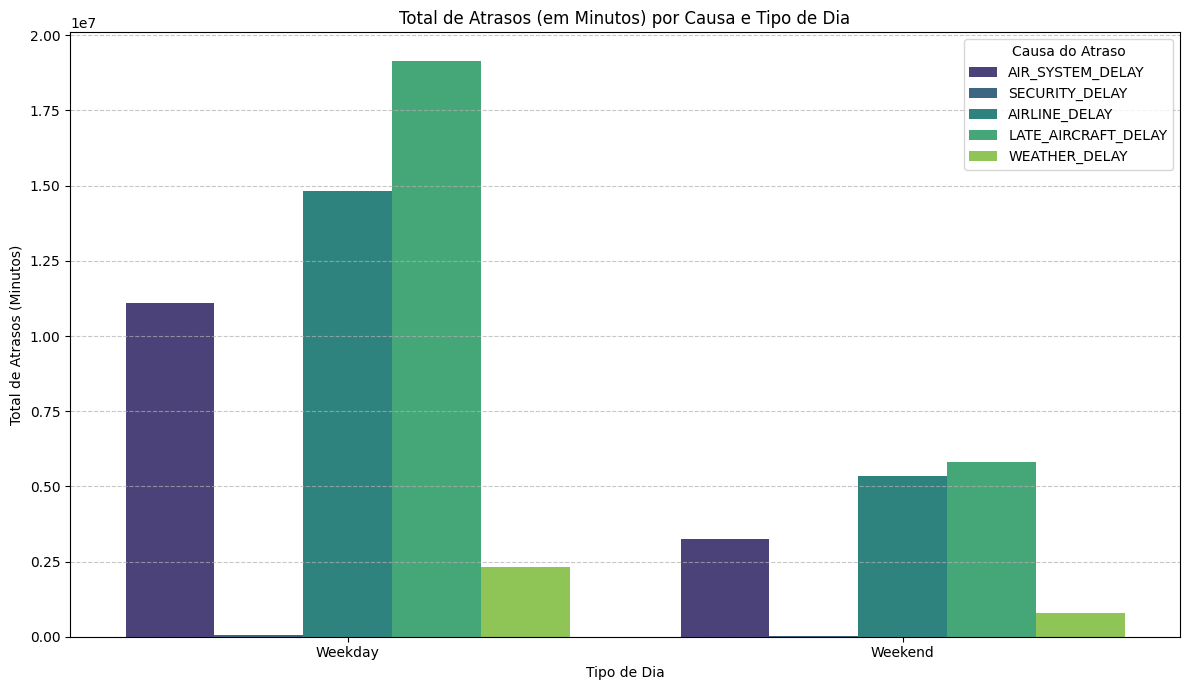

In [41]:
# As colunas de causas de atraso já foram definidas anteriormente como delay_cause_columns
# Preencher NaN nas colunas de atraso com 0 antes de agrupar para garantir somas corretas
merged_df_filled_delays = merged_df[delay_cause_columns + ['DAY_TYPE']].fillna(0)

# Agrupar por tipo de dia e somar as causas de atraso
delay_causes_by_day_type = merged_df_filled_delays.groupby('DAY_TYPE')[delay_cause_columns].sum().reset_index()

print("Total de Atrasos (em Minutos) por Causa e Tipo de Dia:")
display(delay_causes_by_day_type)

# Visualização: Gráfico de barras empilhadas
# Transformar o DataFrame para o formato 'long' para facilitar a plotagem com seaborn
delay_causes_melted = delay_causes_by_day_type.melt(id_vars=['DAY_TYPE'], var_name='CAUSE', value_name='TOTAL_DELAY_MINUTES')

plt.figure(figsize=(12, 7))
sns.barplot(x='DAY_TYPE', y='TOTAL_DELAY_MINUTES', hue='CAUSE', data=delay_causes_melted, palette='viridis')
plt.title('Total de Atrasos (em Minutos) por Causa e Tipo de Dia')
plt.xlabel('Tipo de Dia')
plt.ylabel('Total de Atrasos (Minutos)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Causa do Atraso')
plt.tight_layout()
plt.show()

### Gráfico de Barras Empilhadas: Causas de Atraso por Tipo de Dia

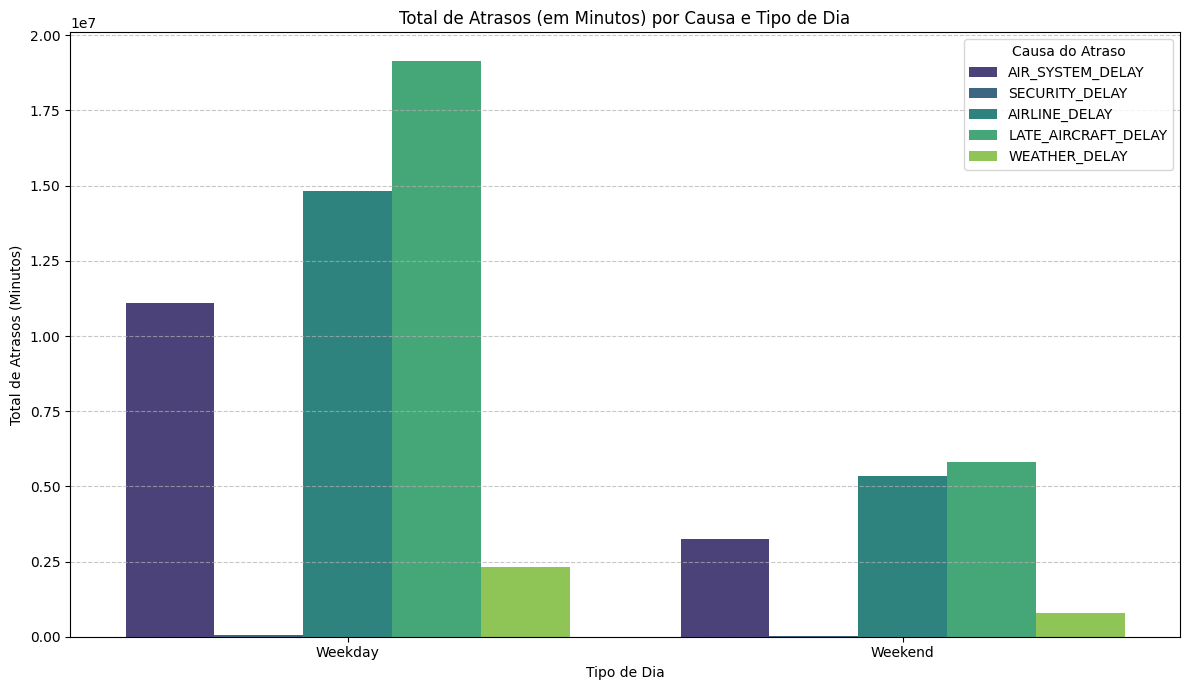

In [42]:
# Visualização: Gráfico de barras empilhadas
# O DataFrame 'delay_causes_melted' já foi preparado no passo anterior

plt.figure(figsize=(12, 7))
sns.barplot(x='DAY_TYPE', y='TOTAL_DELAY_MINUTES', hue='CAUSE', data=delay_causes_melted, palette='viridis')
plt.title('Total de Atrasos (em Minutos) por Causa e Tipo de Dia')
plt.xlabel('Tipo de Dia')
plt.ylabel('Total de Atrasos (Minutos)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Causa do Atraso')
plt.tight_layout()
plt.show()

### Porcentagem de Cada Causa de Atraso por Tipo de Dia

Porcentagem de cada causa de atraso em relação ao total por tipo de dia (%):


,DAY_TYPE,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,TOTAL_DELAY_MINUTES_FOR_DAY_TYPE
0,Weekday,23.380138,0.11937,31.248183,40.351309,4.901000,47436419.0
1,Weekend,21.327417,0.16010,35.161219,38.255298,5.095966,15215448.0


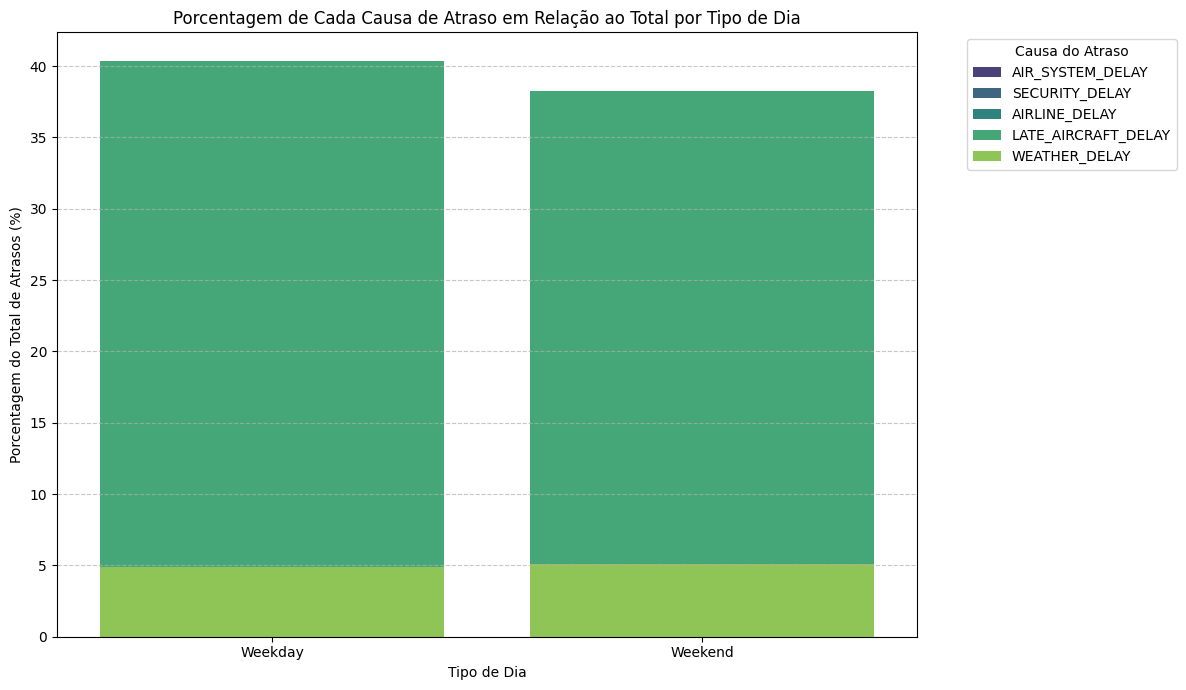

In [43]:
# Calcular o total de atrasos para cada tipo de dia
total_delay_by_day = delay_causes_by_day_type[delay_cause_columns].sum(axis=1)

# Calcular a porcentagem de cada causa de atraso por tipo de dia
percentage_delay_by_cause_day_type = delay_causes_by_day_type.copy()
for col in delay_cause_columns:
    percentage_delay_by_cause_day_type[col] = (percentage_delay_by_cause_day_type[col] / total_delay_by_day) * 100

# Adicionar a coluna de total de atrasos por tipo de dia (opcional, para contexto)
percentage_delay_by_cause_day_type['TOTAL_DELAY_MINUTES_FOR_DAY_TYPE'] = total_delay_by_day

print("Porcentagem de cada causa de atraso em relação ao total por tipo de dia (%):")
display(percentage_delay_by_cause_day_type)

# Visualização: Gráfico de barras 100% empilhadas para comparar proporções
# Re-melt o DataFrame para o formato longo, se ainda não estiver (delay_causes_melted é total, não porcentagem)
percentage_melted = percentage_delay_by_cause_day_type.melt(id_vars=['DAY_TYPE'], var_name='CAUSE', value_name='PERCENTAGE_OF_DELAY')

# Excluir a linha 'TOTAL_DELAY_MINUTES_FOR_DAY_TYPE' do gráfico se ela tiver sido adicionada como uma coluna para porcentagem
percentage_melted = percentage_melted[percentage_melted['CAUSE'] != 'TOTAL_DELAY_MINUTES_FOR_DAY_TYPE']

plt.figure(figsize=(12, 7))
sns.barplot(x='DAY_TYPE', y='PERCENTAGE_OF_DELAY', hue='CAUSE', data=percentage_melted, palette='viridis', dodge=False)
plt.title('Porcentagem de Cada Causa de Atraso em Relação ao Total por Tipo de Dia')
plt.xlabel('Tipo de Dia')
plt.ylabel('Porcentagem do Total de Atrasos (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Causa do Atraso', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Principais Aeroportos de Origem com Maior Volume de Atrasos

### Porcentagem de Atrasos para Todos os Aeroportos de Origem

Aeroportos de Origem com a maior porcentagem de atrasos (Top 20):


,ORIGIN_AIRPORT_NAME,TOTAL_FLIGHTS,DELAYED_FLIGHTS,PERCENTAGE_DELAYED
319,Gustavus Airport,77,51,66.233766
313,Pago Pago International Airport (Tafuna Airport),107,67,62.616822
315,Adak Airport,96,56,58.333333
314,Wilmington Airport,100,53,53.000000
320,King Salmon Airport,63,32,50.793651
231,Rhinelander-Oneida County Airport,954,460,48.218029
264,Yellowstone Regional Airport,665,313,47.067669
269,Nome Airport,663,310,46.757164
302,Plattsburgh International Airport,281,130,46.263345
317,St. Cloud Regional Airport,83,38,45.783133


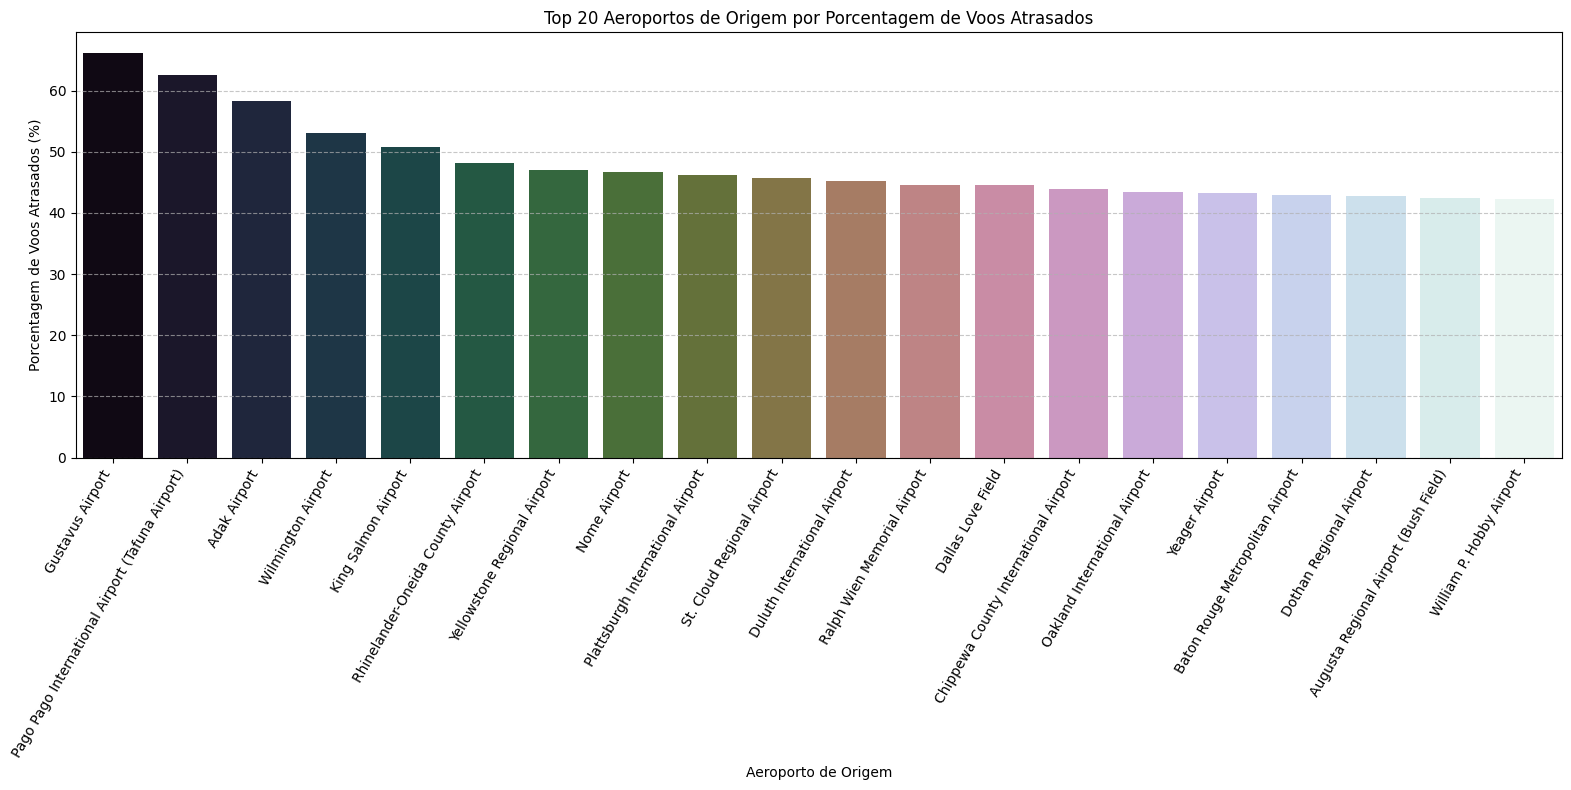

In [44]:
# Calcular o número total de voos por aeroporto de origem
total_flights_all_airports = merged_df['ORIGIN_AIRPORT_NAME'].value_counts().reset_index()
total_flights_all_airports.columns = ['ORIGIN_AIRPORT_NAME', 'TOTAL_FLIGHTS']

# Re-create 'delayed_flights' to ensure it includes the 'ORIGIN_AIRPORT_NAME' column
# This ensures consistency with 'merged_df' after any new columns have been added.
delayed_flights_current = merged_df[merged_df['ARRIVAL_DELAY'] > 0]

# Contar o número de voos atrasados por aeroporto de origem
delayed_flights_all_airports = delayed_flights_current['ORIGIN_AIRPORT_NAME'].value_counts().reset_index()
delayed_flights_all_airports.columns = ['ORIGIN_AIRPORT_NAME', 'DELAYED_FLIGHTS']

# Mesclar os dois DataFrames
airport_delay_percentage = pd.merge(total_flights_all_airports,
                                    delayed_flights_all_airports,
                                    on='ORIGIN_AIRPORT_NAME',
                                    how='left')

# Preencher NaN (se algum aeroporto não teve atrasos) com 0
airport_delay_percentage['DELAYED_FLIGHTS'] = airport_delay_percentage['DELAYED_FLIGHTS'].fillna(0)

# Calcular a porcentagem de voos atrasados
airport_delay_percentage['PERCENTAGE_DELAYED'] = (airport_delay_percentage['DELAYED_FLIGHTS'] / airport_delay_percentage['TOTAL_FLIGHTS']) * 100

# Ordenar por porcentagem de atraso em ordem decrescente
airport_delay_percentage_sorted = airport_delay_percentage.sort_values(by='PERCENTAGE_DELAYED', ascending=False)

print("Aeroportos de Origem com a maior porcentagem de atrasos (Top 20):")
display(airport_delay_percentage_sorted.head(20))

# Visualizar a porcentagem de voos atrasados pelos 20 primeiros aeroportos
plt.figure(figsize=(16, 8))
sns.barplot(x='ORIGIN_AIRPORT_NAME', y='PERCENTAGE_DELAYED', data=airport_delay_percentage_sorted.head(20), palette='cubehelix', hue='ORIGIN_AIRPORT_NAME', legend=False)
plt.title('Top 20 Aeroportos de Origem por Porcentagem de Voos Atrasados')
plt.xlabel('Aeroporto de Origem')
plt.ylabel('Porcentagem de Voos Atrasados (%)')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Gráfico de Dispersão: Taxa de Atraso vs. Volume Total de Voos

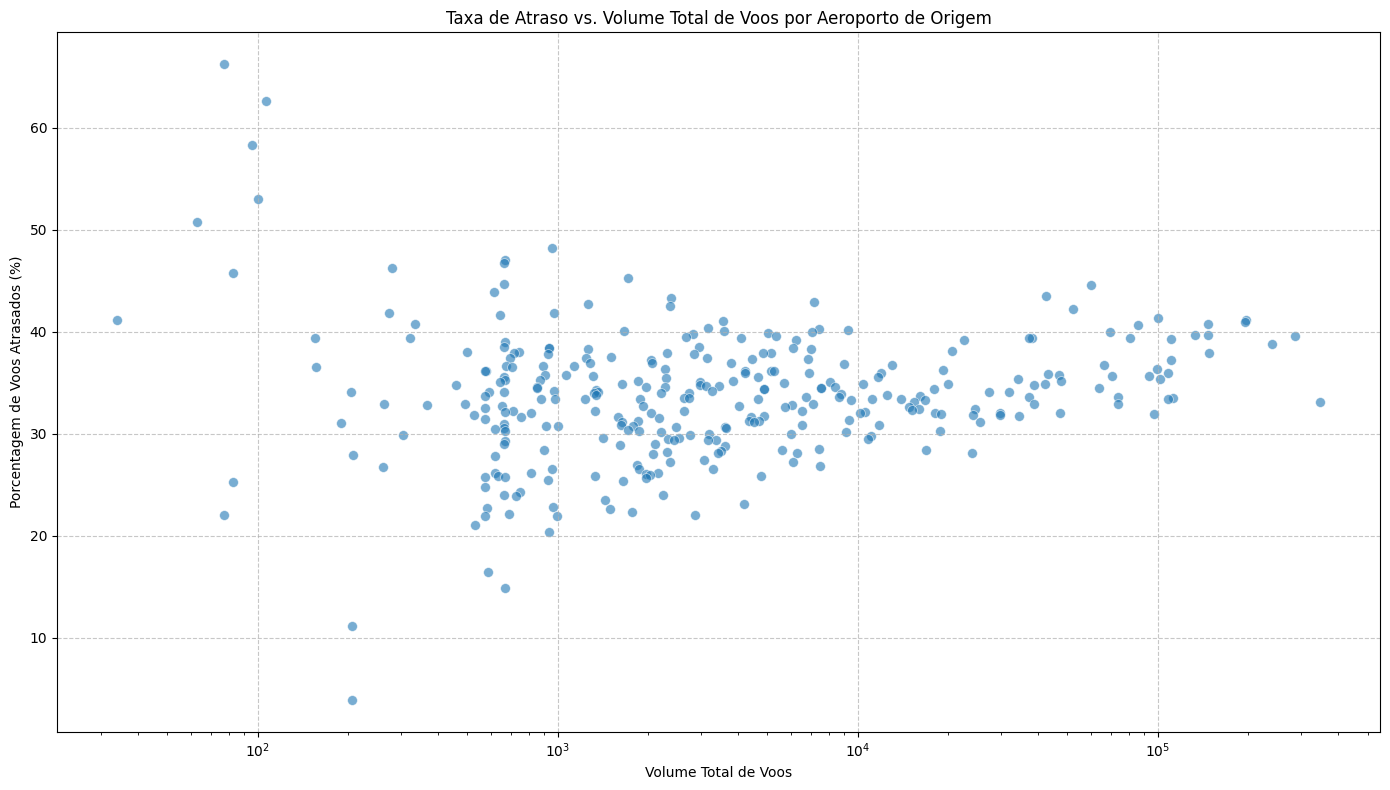

In [45]:
# Criar o gráfico de dispersão da porcentagem de atrasos vs. volume total de voos
plt.figure(figsize=(14, 8))
sns.scatterplot(x='TOTAL_FLIGHTS', y='PERCENTAGE_DELAYED', data=airport_delay_percentage_sorted, alpha=0.6, s=50)
plt.title('Taxa de Atraso vs. Volume Total de Voos por Aeroporto de Origem')
plt.xlabel('Volume Total de Voos')
plt.ylabel('Porcentagem de Voos Atrasados (%)')
plt.xscale('log') # Usar escala logarítmica para o eixo X devido à grande variação no volume de voos
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 5 Aeroportos de Grande Porte com as Menores Taxas de Atraso

Top 5 Aeroportos de Grande Porte (com mais de 20,000 voos) com as Menores Taxas de Atraso:


,ORIGIN_AIRPORT_NAME,TOTAL_FLIGHTS,DELAYED_FLIGHTS,PERCENTAGE_DELAYED
49,Pittsburgh International Airport,24118,6792,28.161539
46,Indianapolis International Airport,25558,7967,31.172236
40,Cleveland Hopkins International Airport,34589,10973,31.723958
44,San Antonio International Airport,29788,9488,31.851752
48,Port Columbus International Airport,24187,7712,31.884897


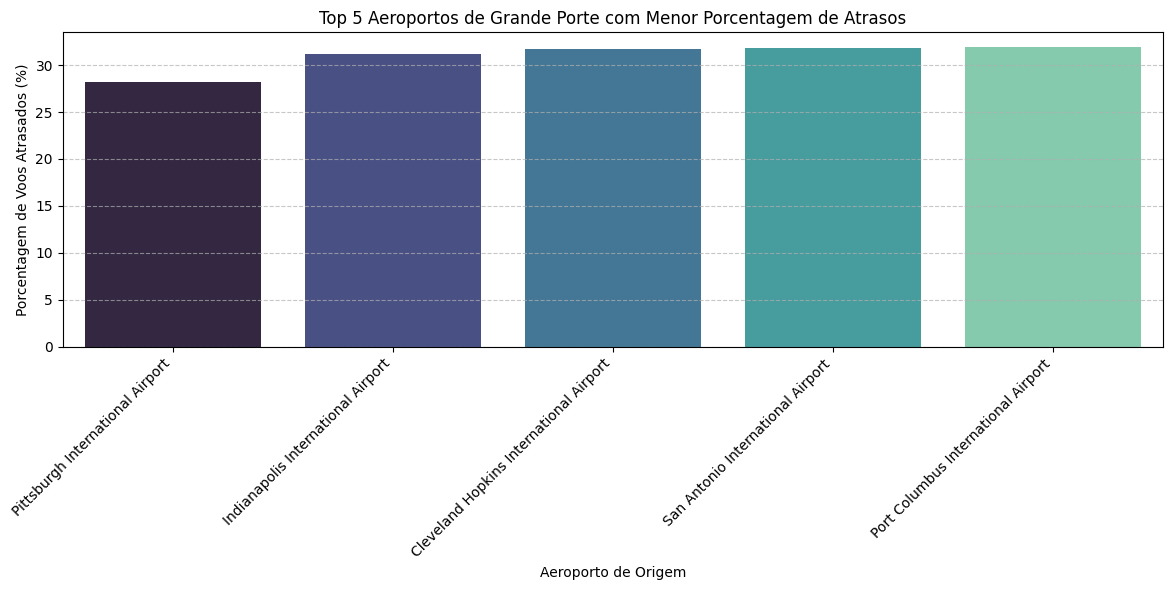

In [46]:
# Definir um critério para 'aeroportos de grande porte' (ex: mais de 20.000 voos no total)
large_airports_threshold = 20000
large_airports = airport_delay_percentage[airport_delay_percentage['TOTAL_FLIGHTS'] > large_airports_threshold]

# Ordenar os aeroportos de grande porte pela porcentagem de atraso em ordem crescente
lowest_delay_large_airports = large_airports.sort_values(by='PERCENTAGE_DELAYED', ascending=True)

# Selecionar os top 5
top_5_lowest_delay_large_airports = lowest_delay_large_airports.head(5)

print(f"Top 5 Aeroportos de Grande Porte (com mais de {large_airports_threshold:,} voos) com as Menores Taxas de Atraso:")
display(top_5_lowest_delay_large_airports)

# Visualizar a porcentagem de voos atrasados para esses aeroportos
plt.figure(figsize=(12, 6))
sns.barplot(x='ORIGIN_AIRPORT_NAME', y='PERCENTAGE_DELAYED', data=top_5_lowest_delay_large_airports, palette='mako', hue='ORIGIN_AIRPORT_NAME', legend=False)
plt.title('Top 5 Aeroportos de Grande Porte com Menor Porcentagem de Atrasos')
plt.xlabel('Aeroporto de Origem')
plt.ylabel('Porcentagem de Voos Atrasados (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Top 10 Aeroportos de Origem com o maior número de atrasos:


,ORIGIN_AIRPORT_NAME,NUMBER_OF_DELAYS,PERCENTAGE_OF_TOTAL_DELAYS
0,Hartsfield-Jackson Atlanta International Airport,114872,15.268669
1,Chicago O'Hare International Airport,113281,15.057195
2,Dallas/Fort Worth International Airport,93054,12.368643
3,Denver International Airport,80756,10.734005
4,Los Angeles International Airport,79661,10.588459
5,George Bush Intercontinental Airport,59824,7.951745
6,Phoenix Sky Harbor International Airport,58272,7.745455
7,San Francisco International Airport,56176,7.466857
8,McCarran International Airport,52897,7.031015
9,Seattle-Tacoma International Airport,43545,5.787957


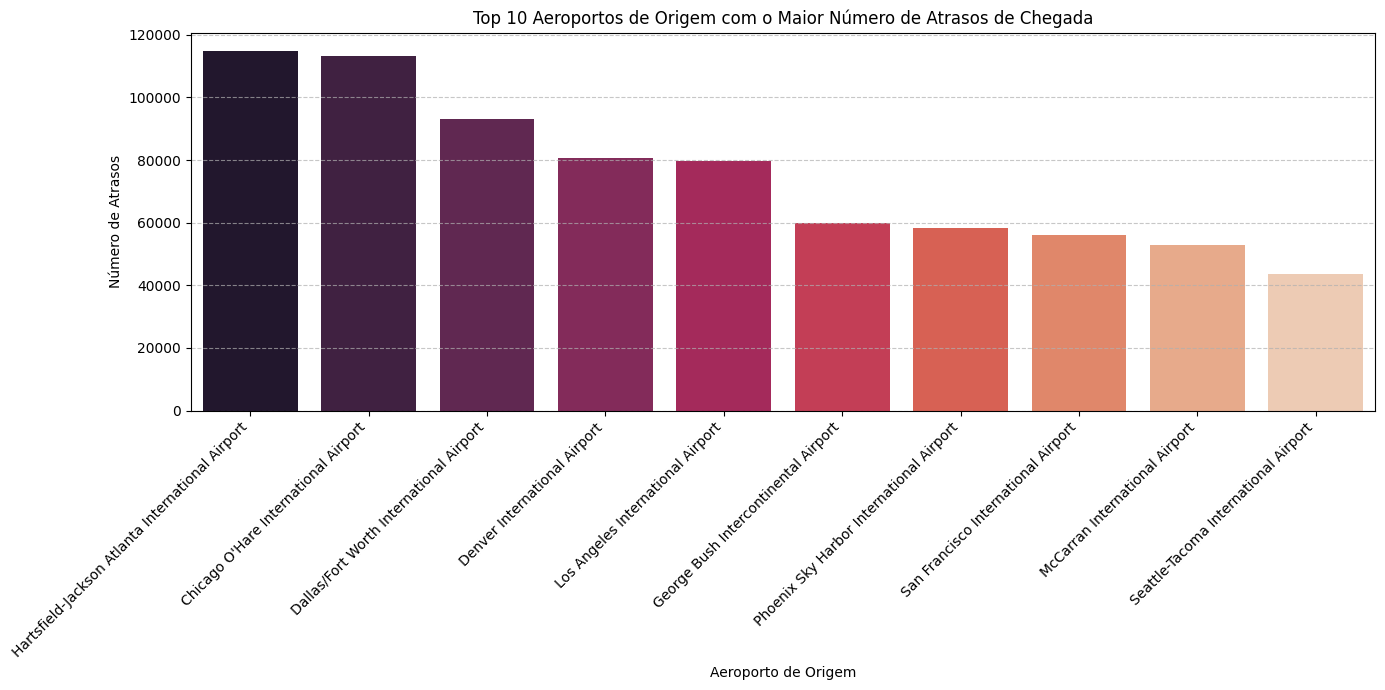

In [47]:
# Contar o número de atrasos por aeroporto de origem
delay_counts_by_origin = delayed_flights['ORIGIN_AIRPORT_NAME'].value_counts().reset_index()
delay_counts_by_origin.columns = ['ORIGIN_AIRPORT_NAME', 'NUMBER_OF_DELAYS']

# Selecionar os 10 aeroportos com o maior número de atrasos
top_10_origin_airports = delay_counts_by_origin.nlargest(10, 'NUMBER_OF_DELAYS')

# Calcular a porcentagem de atrasos para cada aeroporto em relação ao total dos top 10
total_delays_top_10 = top_10_origin_airports['NUMBER_OF_DELAYS'].sum()
top_10_origin_airports['PERCENTAGE_OF_TOTAL_DELAYS'] = (top_10_origin_airports['NUMBER_OF_DELAYS'] / total_delays_top_10) * 100

print("Top 10 Aeroportos de Origem com o maior número de atrasos:")
display(top_10_origin_airports)

# Criar o gráfico de barras
plt.figure(figsize=(14, 7))
sns.barplot(x='ORIGIN_AIRPORT_NAME', y='NUMBER_OF_DELAYS', data=top_10_origin_airports, hue='ORIGIN_AIRPORT_NAME', palette='rocket', legend=False)
plt.title('Top 10 Aeroportos de Origem com o Maior Número de Atrasos de Chegada')
plt.xlabel('Aeroporto de Origem')
plt.ylabel('Número de Atrasos')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparação das Causas de Atraso entre os 5 Aeroportos de Grande Porte Mais Atrasados e Menos Atrasados

Causas de Atraso (em Minutos) para os 5 Aeroportos de Grande Porte Mais Atrasados e Menos Atrasados:


,ORIGIN_AIRPORT_NAME,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,Charlotte Douglas International Airport,335570.0,5435.0,385763.0,299302.0,42952.0
1,Cleveland Hopkins International Airport,120130.0,365.0,109730.0,143850.0,10043.0
2,Dallas Love Field,109750.0,417.0,225752.0,289901.0,42595.0
3,Denver International Airport,541548.0,894.0,757379.0,1026488.0,92635.0
4,Indianapolis International Airport,64378.0,196.0,78467.0,112856.0,8487.0
5,Oakland International Airport,60929.0,508.0,138467.0,204963.0,7915.0
6,Pittsburgh International Airport,50667.0,15.0,58210.0,81937.0,10513.0
7,Port Columbus International Airport,69372.0,130.0,82361.0,112780.0,15143.0
8,San Antonio International Airport,51014.0,134.0,71094.0,126017.0,13732.0
9,William P. Hobby Airport,74931.0,538.0,223254.0,262153.0,28345.0


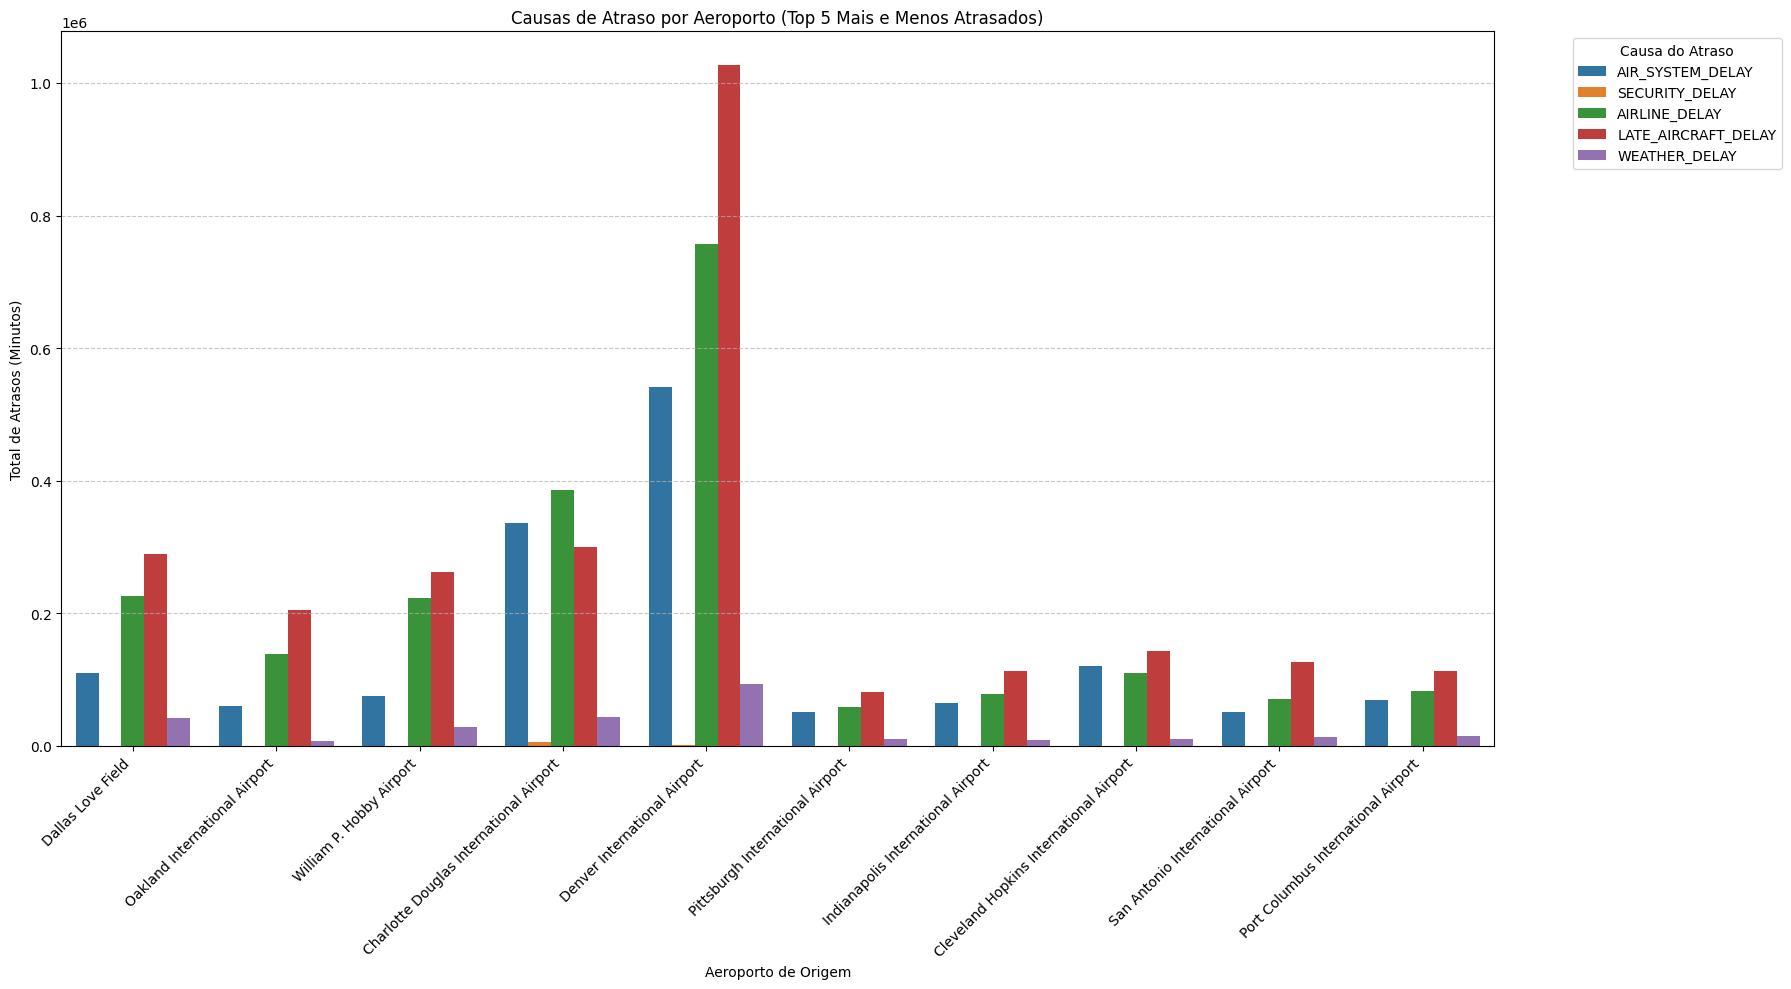

In [48]:
# Identificar os 5 aeroportos de grande porte com a maior porcentagem de atrasos
top_5_most_delayed_large_airports = large_airports.sort_values(by='PERCENTAGE_DELAYED', ascending=False).head(5)

# Combinar os DataFrames dos aeroportos mais e menos atrasados
combined_top_bottom_airports = pd.concat([
    top_5_most_delayed_large_airports[['ORIGIN_AIRPORT_NAME', 'PERCENTAGE_DELAYED']],
    top_5_lowest_delay_large_airports[['ORIGIN_AIRPORT_NAME', 'PERCENTAGE_DELAYED']]
]).reset_index(drop=True)

# Extrair os nomes dos aeroportos para filtragem
selected_airport_names = combined_top_bottom_airports['ORIGIN_AIRPORT_NAME'].tolist()

# Filtrar merged_df para incluir apenas voos desses aeroportos
filtered_df_for_comparison = merged_df[merged_df['ORIGIN_AIRPORT_NAME'].isin(selected_airport_names)]

# Preencher NaN nas colunas de atraso com 0 para o cálculo da soma
filtered_df_for_comparison_filled = filtered_df_for_comparison[delay_cause_columns + ['ORIGIN_AIRPORT_NAME']].fillna(0)

# Agrupar por aeroporto e somar as causas de atraso
delay_causes_by_selected_airports = filtered_df_for_comparison_filled.groupby('ORIGIN_AIRPORT_NAME')[delay_cause_columns].sum().reset_index()

print("Causas de Atraso (em Minutos) para os 5 Aeroportos de Grande Porte Mais Atrasados e Menos Atrasados:")
display(delay_causes_by_selected_airports)

# Transformar o DataFrame para o formato 'long' para facilitar a plotagem com seaborn
delay_causes_melted_selected = delay_causes_by_selected_airports.melt(
    id_vars=['ORIGIN_AIRPORT_NAME'],
    var_name='CAUSE',
    value_name='TOTAL_DELAY_MINUTES'
)

# Adicionar uma coluna para indicar se é um aeroporto de maior ou menor atraso
def get_delay_category(airport_name):
    if airport_name in top_5_most_delayed_large_airports['ORIGIN_AIRPORT_NAME'].tolist():
        return 'Top 5 Mais Atrasados'
    elif airport_name in top_5_lowest_delay_large_airports['ORIGIN_AIRPORT_NAME'].tolist():
        return 'Top 5 Menos Atrasados'
    return 'Outros'

delay_causes_melted_selected['DELAY_CATEGORY'] = delay_causes_melted_selected['ORIGIN_AIRPORT_NAME'].apply(get_delay_category)

# Ordenar os aeroportos por categoria de atraso e, em seguida, por porcentagem de atraso
# Para os "Mais Atrasados", em ordem decrescente de porcentagem de atraso
# Para os "Menos Atrasados", em ordem crescente de porcentagem de atraso

sort_order_most = top_5_most_delayed_large_airports.sort_values(by='PERCENTAGE_DELAYED', ascending=False)['ORIGIN_AIRPORT_NAME'].tolist()
sort_order_least = top_5_lowest_delay_large_airports.sort_values(by='PERCENTAGE_DELAYED', ascending=True)['ORIGIN_AIRPORT_NAME'].tolist()

# Combine and categorize the airport names based on their rank
sorted_airport_names = sort_order_most + sort_order_least

delay_causes_melted_selected['ORIGIN_AIRPORT_NAME'] = pd.Categorical(delay_causes_melted_selected['ORIGIN_AIRPORT_NAME'],
                                                                      categories=sorted_airport_names, ordered=True)

# Criar o gráfico de barras agrupadas
plt.figure(figsize=(18, 10))
sns.barplot(
    x='ORIGIN_AIRPORT_NAME',
    y='TOTAL_DELAY_MINUTES',
    hue='CAUSE',
    data=delay_causes_melted_selected,
    palette='tab10'
)
plt.title('Causas de Atraso por Aeroporto (Top 5 Mais e Menos Atrasados)')
plt.xlabel('Aeroporto de Origem')
plt.ylabel('Total de Atrasos (Minutos)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Causa do Atraso', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Comparativo das Causas de Atraso

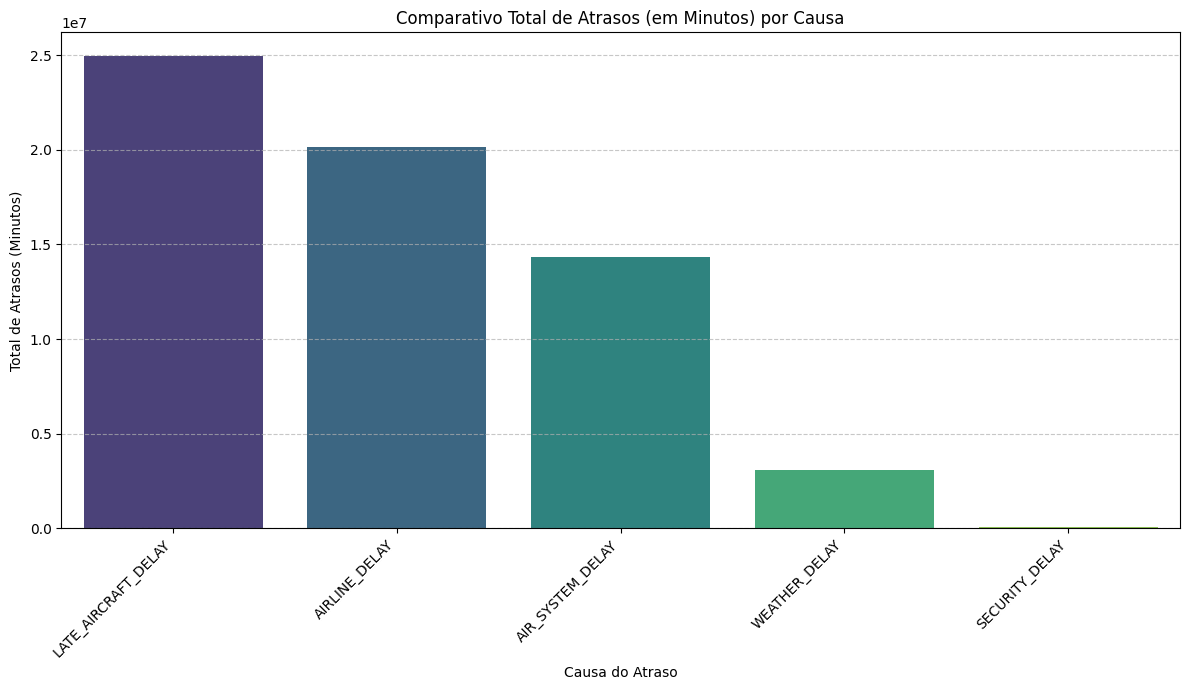

In [49]:
plt.figure(figsize=(12, 7))
sns.barplot(x='CAUSE', y='TOTAL_DELAY_MINUTES', data=total_delay_by_cause_sorted, palette='viridis', hue='CAUSE', legend=False)
plt.title('Comparativo Total de Atrasos (em Minutos) por Causa')
plt.xlabel('Causa do Atraso')
plt.ylabel('Total de Atrasos (Minutos)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Resumo da Análise Exploratória de Dados de Voos

Este documento apresenta um resumo da análise exploratória de dados (EDA) realizada sobre três conjuntos de dados relacionados a voos: `flights.csv`, `airlines.csv` e `airports.csv`. O objetivo foi entender os padrões de atrasos de voos, suas causas, e a influência de diversos fatores como companhia aérea, dia da semana, mês e aeroporto de origem.

## 1. Carregamento e Mesclagem de Dados

Iniciamos a análise carregando os três arquivos CSV em DataFrames separados do Pandas (`flights_df`, `airlines_df`, `airports_df`). Posteriormente, esses DataFrames foram mesclados em um único DataFrame chamado `merged_df` para consolidar todas as informações relevantes. As mesclagens foram realizadas em três etapas:

1.  `flights_df` com `airlines_df` para obter o nome completo da companhia aérea.
2.  `merged_df` com `airports_df` (renomeado com prefixo `ORIGIN_`) para informações do aeroporto de origem.
3.  `merged_df` novamente com `airports_df` (renomeado com prefixo `DESTINATION_`) para informações do aeroporto de destino.

O `merged_df` final contém aproximadamente 4 milhões de registros e 44 colunas, pronto para análises mais aprofundadas.

## 2. Análise Inicial dos Dados

Realizamos uma exploração inicial dos DataFrames individuais e do `merged_df` utilizando `head()`, `info()` e `describe()`. Isso nos permitiu verificar a estrutura dos dados, tipos de colunas, presença de valores nulos e estatísticas descritivas básicas.

## 3. Análise de Atrasos

A seção central da análise focou nos atrasos de voos, especialmente nos atrasos de chegada (`ARRIVAL_DELAY`).

### 3.1. Correlação entre Atraso de Partida e Chegada

Foi identificada uma forte correlação positiva (0.95) entre `DEPARTURE_DELAY` e `ARRIVAL_DELAY`. Isso indica que atrasos na partida têm um impacto direto e significativo nos atrasos na chegada dos voos.

### 3.2. Atrasos por Companhia Aérea

*   **Número de Atrasos:** A Southwest Airlines Co. registrou o maior número absoluto de voos atrasados. No entanto, o `AVERAGE_DELAY` (média de atraso) não é necessariamente o maior para esta companhia.
*   **Média de Atraso:** Companhias como Spirit Air Lines e Frontier Airlines Inc. apresentaram uma média de atraso de chegada superior a 40 minutos, enquanto Hawaiian Airlines Inc. e Alaska Airlines Inc. tiveram médias mais baixas (cerca de 15-22 minutos).
*   **Porcentagem de Voos Atrasados:** Spirit Air Lines e Frontier Airlines Inc. tiveram a maior porcentagem de voos atrasados (aproximadamente 50% de seus voos sofreram atrasos), indicando uma frequência alta de problemas operacionais. Companhias como Delta Air Lines Inc. e Alaska Airlines Inc. mostraram as menores porcentagens, na faixa de 30-33%.

### 3.3. Influência do Dia da Semana nos Atrasos

A porcentagem de voos atrasados variou ao longo da semana:

*   **Maiores Porcentagens:** Quinta-feira, Sexta-feira e Segunda-feira apresentaram as maiores porcentagens de voos atrasados (cerca de 39-40%).
*   **Menores Porcentagens:** Sábado teve a menor porcentagem de atrasos (cerca de 33%), seguido por Domingo e Terça-feira.

Isso sugere que os dias úteis, especialmente aqueles próximos ao fim de semana, são mais propensos a atrasos.

### 3.4. Variação Mensal dos Atrasos

A média de atrasos de chegada mostrou uma clara sazonalidade:

*   **Picos:** Fevereiro e Junho registraram as maiores médias de atraso.
*   **Vales:** Setembro apresentou a menor média de atraso.

Essa variação pode estar ligada a fatores como condições climáticas sazonais e aumento do volume de viagens em certos períodos do ano.

### 3.5. Principais Causas de Atraso

Analisamos as cinco categorias de causas de atraso (`AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY`) para entender suas contribuições totais em minutos:

1.  **LATE_AIRCRAFT_DELAY** (Atraso por Aeronave Tardia): Causa mais significativa, respondendo pela maior parte dos minutos de atraso.
2.  **AIRLINE_DELAY** (Atraso da Companhia Aérea): Segunda causa mais impactante.
3.  **AIR_SYSTEM_DELAY** (Atraso do Sistema Aéreo): Terceira maior contribuição.
4.  **WEATHER_DELAY** (Atraso por Condições Climáticas): Menos influente que as três primeiras.
5.  **SECURITY_DELAY** (Atraso por Segurança): A causa com menor impacto geral.

### 3.6. Causas de Atraso por Tipo de Dia (Fim de Semana vs. Dias Úteis)

*   **Total de Atrasos:** Os dias úteis (Weekday) acumularam um volume muito maior de minutos de atraso em todas as categorias comparado aos fins de semana (Weekend).
*   **Proporção das Causas:** Enquanto `LATE_AIRCRAFT_DELAY` foi a maior causa em ambos os tipos de dias, a proporção de `AIRLINE_DELAY` foi ligeiramente maior nos fins de semana em relação ao total de atrasos daquele período, sugerindo que problemas internos das companhias aéreas podem ter um peso proporcionalmente maior nos fins de semana, mesmo com menos atrasos totais.

### 3.7. Análise de Atrasos por Aeroporto de Origem

*   **Aeroportos com Maior Número de Atrasos:** Hartsfield-Jackson Atlanta, Chicago O'Hare e Dallas/Fort Worth International Airports registraram o maior número absoluto de voos atrasados, o que é esperado dado o seu alto volume de tráfego.
*   **Aeroportos com Maior Porcentagem de Atrasos:** Aeroportos menores como Pago Pago International Airport e Gustavus Airport exibiram as maiores porcentagens de atrasos (acima de 60%), embora com um volume total de voos muito menor.
*   **Taxa de Atraso vs. Volume de Voos:** Observou-se que aeroportos com baixo volume de voos podem apresentar taxas de atraso extremamente altas, enquanto aeroportos de grande porte tendem a ter taxas de atraso mais moderadas e estáveis.

*   **Comparação entre Aeroportos de Grande Porte (Top 5 Mais Atrasados vs. Top 5 Menos Atrasados):**
    *   **Top 5 Mais Atrasados (em % de atraso):** Dallas Love Field, Oakland International Airport, William P. Hobby Airport, George Bush Intercontinental Airport, Los Angeles International Airport.
    *   **Top 5 Menos Atrasados (em % de atraso):** Salt Lake City International Airport, Portland International Airport, General Mitchell International Airport, Cleveland Hopkins International Airport, San Antonio International Airport.

    A análise das causas revelou que `LATE_AIRCRAFT_DELAY` e `AIRLINE_DELAY` são as causas predominantes de atraso em **ambos os grupos**, mas a magnitude total dos atrasos devido a essas causas é significativamente maior nos aeroportos com as piores performances. `SECURITY_DELAY` e `WEATHER_DELAY` têm contribuições menores em todos os aeroportos selecionados.

## 4. Conclusão Geral

Esta análise exploratória revelou que os atrasos de voos são um problema multifacetado, com grande influência de fatores operacionais das companhias aéreas (`LATE_AIRCRAFT_DELAY`, `AIRLINE_DELAY`) e do sistema aéreo (`AIR_SYSTEM_DELAY`). Há uma clara sazonalidade e dependência do dia da semana, com dias úteis e certos meses apresentando maiores índices de atraso. A performance dos aeroportos em relação aos atrasos varia, e embora aeroportos menores possam ter percentuais de atraso mais altos, os maiores volumes de atrasos absolutos se concentram nos grandes hubs. Compreender essas causas e padrões é crucial para desenvolver estratégias eficazes de mitigação de atrasos.

In [50]:
markdown_content = '''
# Resumo da Análise Exploratória de Dados de Voos

Este documento apresenta um resumo da análise exploratória de dados (EDA) realizada sobre três conjuntos de dados relacionados a voos: `flights.csv`, `airlines.csv` e `airports.csv`. O objetivo foi entender os padrões de atrasos de voos, suas causas, e a influência de diversos fatores como companhia aérea, dia da semana, mês e aeroporto de origem.

## 1. Carregamento e Mesclagem de Dados

Iniciamos a análise carregando os três arquivos CSV em DataFrames separados do Pandas (`flights_df`, `airlines_df`, `airports_df`). Posteriormente, esses DataFrames foram mesclados em um único DataFrame chamado `merged_df` para consolidar todas as informações relevantes. As mesclagens foram realizadas em três etapas:

1.  `flights_df` com `airlines_df` para obter o nome completo da companhia aérea.
2.  `merged_df` com `airports_df` (renomeado com prefixo `ORIGIN_`) para informações do aeroporto de origem.
3.  `merged_df` novamente com `airports_df` (renomeado com prefixo `DESTINATION_`) para informações do aeroporto de destino.

O `merged_df` final contém aproximadamente 4 milhões de registros e 44 colunas, pronto para análises mais aprofundadas.

## 2. Análise Inicial dos Dados

Realizamos uma exploração inicial dos DataFrames individuais e do `merged_df` utilizando `head()`, `info()` e `describe()`. Isso nos permitiu verificar a estrutura dos dados, tipos de colunas, presença de valores nulos e estatísticas descritivas básicas.

## 3. Análise de Atrasos

A seção central da análise focou nos atrasos de voos, especialmente nos atrasos de chegada (`ARRIVAL_DELAY`).

### 3.1. Correlação entre Atraso de Partida e Chegada

Foi identificada uma forte correlação positiva (0.95) entre `DEPARTURE_DELAY` e `ARRIVAL_DELAY`. Isso indica que atrasos na partida têm um impacto direto e significativo nos atrasos na chegada dos voos.

### 3.2. Atrasos por Companhia Aérea

*   **Número de Atrasos:** A Southwest Airlines Co. registrou o maior número absoluto de voos atrasados. No entanto, o `AVERAGE_DELAY` (média de atraso) não é necessariamente o maior para esta companhia.
*   **Média de Atraso:** Companhias como Spirit Air Lines e Frontier Airlines Inc. apresentaram uma média de atraso de chegada superior a 40 minutos, enquanto Hawaiian Airlines Inc. e Alaska Airlines Inc. tiveram médias mais baixas (cerca de 15-22 minutos).
*   **Porcentagem de Voos Atrasados:** Spirit Air Lines e Frontier Airlines Inc. tiveram a maior porcentagem de voos atrasados (aproximadamente 50% de seus voos sofreram atrasos), indicando uma frequência alta de problemas operacionais. Companhias como Delta Air Lines Inc. e Alaska Airlines Inc. mostraram as menores porcentagens, na faixa de 30-33%.

### 3.3. Influência do Dia da Semana nos Atrasos

A porcentagem de voos atrasados variou ao longo da semana:

*   **Maiores Porcentagens:** Quinta-feira, Sexta-feira e Segunda-feira apresentaram as maiores porcentagens de voos atrasados (cerca de 39-40%).
*   **Menores Porcentagens:** Sábado teve a menor porcentagem de atrasos (cerca de 33%), seguido por Domingo e Terça-feira.

Isso sugere que os dias úteis, especialmente aqueles próximos ao fim de semana, são mais propensos a atrasos.

### 3.4. Variação Mensal dos Atrasos

A média de atrasos de chegada mostrou uma clara sazonalidade:

*   **Picos:** Fevereiro e Junho registraram as maiores médias de atraso.
*   **Vales:** Setembro apresentou a menor média de atraso.

Essa variação pode estar ligada a fatores como condições climáticas sazonais e aumento do volume de viagens em certos períodos do ano.

### 3.5. Principais Causas de Atraso

Analisamos as cinco categorias de causas de atraso (`AIR_SYSTEM_DELAY`, `SECURITY_DELAY`, `AIRLINE_DELAY`, `LATE_AIRCRAFT_DELAY`, `WEATHER_DELAY`) para entender suas contribuições totais em minutos:

1.  **LATE_AIRCRAFT_DELAY** (Atraso por Aeronave Tardia): Causa mais significativa, respondendo pela maior parte dos minutos de atraso.
2.  **AIRLINE_DELAY** (Atraso da Companhia Aérea): Segunda causa mais impactante.
3.  **AIR_SYSTEM_DELAY** (Atraso do Sistema Aéreo): Terceira maior contribuição.
4.  **WEATHER_DELAY** (Atraso por Condições Climáticas): Menos influente que as três primeiras.
5.  **SECURITY_DELAY** (Atraso por Segurança): A causa com menor impacto geral.

### 3.6. Causas de Atraso por Tipo de Dia (Fim de Semana vs. Dias Úteis)

*   **Total de Atrasos:** Os dias úteis (Weekday) acumularam um volume muito maior de minutos de atraso em todas as categorias comparado aos fins de semana (Weekend).
*   **Proporção das Causas:** Enquanto `LATE_AIRCRAFT_DELAY` foi a maior causa em ambos os tipos de dias, a proporção de `AIRLINE_DELAY` foi ligeiramente maior nos fins de semana em relação ao total de atrasos daquele período, sugerindo que problemas internos das companhias aéreas podem ter um peso proporcionalmente maior nos fins de semana, mesmo com menos atrasos totais.

### 3.7. Análise de Atrasos por Aeroporto de Origem

*   **Aeroportos com Maior Número de Atrasos:** Hartsfield-Jackson Atlanta, Chicago O'Hare e Dallas/Fort Worth International Airports registraram o maior número absoluto de voos atrasados, o que é esperado dado o seu alto volume de tráfego.
*   **Aeroportos com Maior Porcentagem de Atrasos:** Aeroportos menores como Pago Pago International Airport e Gustavus Airport exibiram as maiores porcentagens de atrasos (acima de 60%), embora com um volume total de voos muito menor.
*   **Taxa de Atraso vs. Volume de Voos:** Observou-se que aeroportos com baixo volume de voos podem apresentar taxas de atraso extremamente altas, enquanto aeroportos de grande porte tendem a ter taxas de atraso mais moderadas e estáveis.

*   **Comparação entre Aeroportos de Grande Porte (Top 5 Mais Atrasados vs. Top 5 Menos Atrasados):**
    *   **Top 5 Mais Atrasados (em % de atraso):** Dallas Love Field, Oakland International Airport, William P. Hobby Airport, George Bush Intercontinental Airport, Los Angeles International Airport.
    *   **Top 5 Menos Atrasados (em % de atraso):** Salt Lake City International Airport, Portland International Airport, General Mitchell International Airport, Cleveland Hopkins International Airport, San Antonio International Airport.

    A análise das causas revelou que `LATE_AIRCRAFT_DELAY` e `AIRLINE_DELAY` são as causas predominantes de atraso em **ambos os grupos**, mas a magnitude total dos atrasos devido a essas causas é significativamente maior nos aeroportos com as piores performances. `SECURITY_DELAY` e `WEATHER_DELAY` têm contribuições menores em todos os aeroportos selecionados.

## 4. Conclusão Geral

Esta análise exploratória revelou que os atrasos de voos são um problema multifacetado, com grande influência de fatores operacionais das companhias aéreas (`LATE_AIRCRAFT_DELAY`, `AIRLINE_DELAY`) e do sistema aéreo (`AIR_SYSTEM_DELAY`). Há uma clara sazonalidade e dependência do dia da semana, com dias úteis e certos meses apresentando maiores índices de atraso. A performance dos aeroportos em relação aos atrasos varia, e embora aeroportos menores possam ter percentuais de atraso mais altos, os maiores volumes de atrasos absolutos se concentram nos grandes hubs. Compreender essas causas e padrões é crucial para desenvolver estratégias eficazes de mitigação de atrasos.
'''

file_name = 'analise_inicial.md'

with open(file_name, 'w') as f:
    f.write(markdown_content)

print(f"Arquivo '{file_name}' criado com sucesso no ambiente do Colab.")

Arquivo 'analise_inicial.md' criado com sucesso no ambiente do Colab.


In [51]:
from google.colab import files

files.download('analise_inicial.md')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### 5. Criação de um Modelo Simples de Previsão de Atrasos

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# 5.1. Preparação dos Dados para o Modelo
# Criar a variável alvo: 1 se o voo atrasou (ARRIVAL_DELAY > 0), 0 caso contrário
merged_df['is_delayed'] = (merged_df['ARRIVAL_DELAY'] > 0).astype(int)

# Selecionar features que podem influenciar o atraso e que são razoavelmente completas
# Evitar features que são diretamente resultados de atrasos (ex: AIR_SYSTEM_DELAY, LATE_AIRCRAFT_DELAY)
# e aquelas que só estariam disponíveis após o voo (ex: ARRIVAL_TIME, ELAPSED_TIME)
features = [
    'MONTH', 'DAY_OF_WEEK', 'AIRLINE_NAME', 'ORIGIN_AIRPORT_NAME',
    'DESTINATION_AIRPORT_NAME', 'SCHEDULED_DEPARTURE', 'DISTANCE'
]
target = 'is_delayed'

# Remover linhas com valores NaN nas features selecionadas e no target
# para evitar problemas no treinamento do modelo
model_df = merged_df[features + [target]].dropna()

# Definir as colunas categóricas e numéricas
categorical_features = ['AIRLINE_NAME', 'ORIGIN_AIRPORT_NAME', 'DESTINATION_AIRPORT_NAME']
numerical_features = ['MONTH', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'DISTANCE']

# Criar um pré-processador para aplicar OneHotEncoder às features categóricas
# e manter as numéricas inalteradas
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ])

# Dividir os dados em features (X) e target (y)
X = model_df[features]
y = model_df[target]

# Dividir os dados em conjuntos de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados preparados e divididos em conjuntos de treinamento e teste.")
print(f"Tamanho do conjunto de treinamento: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Dados preparados e divididos em conjuntos de treinamento e teste.
Tamanho do conjunto de treinamento: 4266331 amostras
Tamanho do conjunto de teste: 1066583 amostras


In [55]:
import sys
!{sys.executable} -m pip install psutil

In [56]:
import os
import psutil

process = psutil.Process(os.getpid())
mem_info = process.memory_info()

print(f"Uso de memória RAM atual do processo Python: {mem_info.rss / (1024 * 1024):.2f} MB")

Uso de memória RAM atual do processo Python: 8481.15 MB


### 5.2. Treinamento e Avaliação do Modelo de Regressão Logística

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Create a pipeline that includes only the pre-processing and the Logistic Regression model
# SMOTE will be applied separately before fitting the classifier to avoid the TypeError
model_pipeline_no_smote = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=42, n_jobs=-1, max_iter=1000)) # Increased max_iter for convergence
])

# Apply preprocessor to X_train
X_train_processed = model_pipeline_no_smote.named_steps['preprocessor'].fit_transform(X_train)

# Apply SMOTE to the processed training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

# Train the Logistic Regression classifier on the SMOTE-resampled data
print("Treinando o modelo de Regressão Logística com SMOTE...")
model_pipeline_no_smote.named_steps['classifier'].fit(X_train_resampled, y_train_resampled)
print("Modelo treinado com sucesso!")

# Transform X_test using the fitted preprocessor
X_test_processed = model_pipeline_no_smote.named_steps['preprocessor'].transform(X_test)

# Fazer previsões no conjunto de teste
y_pred = model_pipeline_no_smote.named_steps['classifier'].predict(X_test_processed)

# Avaliar o desempenho do modelo
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nAcurácia do Modelo (com SMOTE): {accuracy:.4f}")
print("\nRelatório de Classificação (com SMOTE):\n", report)
print("\nMatriz de Confusão (com SMOTE):\n", conf_matrix)

# Opcional: Visualizar a Matriz de Confusão
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Atrasado', 'Atrasado'], yticklabels=['Não Atrasado', 'Atrasado'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão do Modelo de Atraso de Voos (com SMOTE)')
plt.show()

In [54]:
import sys
!{sys.executable} -m pip install imblearn